<a href="https://colab.research.google.com/github/batgirlsupimpa/UFSC/blob/main/TCC_FINAL_BIBI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# ============================================================
# TCC 2026 — BIANCA
# China e Índia | CGV, produtividade e inserção internacional
#
# CÉLULA 1 — AMBIENTE E FONTES
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pasta onde estão as bases originais
PASTA = (
    "/content/drive/MyDrive/"
    "DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca"
)

# Arquivos que já sabemos que existem no Drive
ARQUIVOS = {
    "DVA_TiVA": "EXGR_DVASH.csv",
    "PWT": "pwt110.xlsx",
    "ECI": "growth_proj_eci_rankings.csv"
}

print("=" * 70)
print("AUDITORIA DOS ARQUIVOS")
print("=" * 70)

for nome, arquivo in ARQUIVOS.items():

    caminho = os.path.join(PASTA, arquivo)

    print(
        f"{nome:15s}",
        "OK" if os.path.exists(caminho) else "NÃO ENCONTRADO",
        "|",
        arquivo
    )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AUDITORIA DOS ARQUIVOS
DVA_TiVA        OK | EXGR_DVASH.csv
PWT             OK | pwt110.xlsx
ECI             OK | growth_proj_eci_rankings.csv


In [27]:
# ============================================================
# CÉLULA 2 — CARREGAR E VALIDAR TiVA / DVA
# ============================================================

ARQ_DVA = os.path.join(PASTA, ARQUIVOS["DVA_TiVA"])

dva_original = pd.read_csv(ARQ_DVA)

print("=" * 70)
print("BASE TiVA ORIGINAL")
print("=" * 70)

print("Dimensão:", dva_original.shape)
print("\nColunas:")
print(dva_original.columns.tolist())

print("\nValores únicos principais:")
print("MEASURE:", dva_original["MEASURE"].unique()[:10])
print("UNIT_MEASURE:", dva_original["UNIT_MEASURE"].unique()[:10])
print("COUNTERPART_AREA:", dva_original["COUNTERPART_AREA"].unique()[:10])

# ------------------------------------------------------------
# Total da economia (_T)
# ------------------------------------------------------------

dva = (
    dva_original
    .loc[dva_original["ACTIVITY"].eq("_T"),
         ["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]]
    .rename(columns={
        "REF_AREA": "country",
        "TIME_PERIOD": "year",
        "OBS_VALUE": "DVA_SHARE"
    })
    .copy()
)

dva["year"] = pd.to_numeric(dva["year"], errors="coerce")
dva["DVA_SHARE"] = pd.to_numeric(dva["DVA_SHARE"], errors="coerce")

dva = (
    dva
    .dropna(subset=["country", "year", "DVA_SHARE"])
    .sort_values(["country", "year"])
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("BASE DVA LIMPA")
print("=" * 70)

print("Observações:", len(dva))
print("Países:", dva["country"].nunique())
print("Período:", int(dva["year"].min()), "-", int(dva["year"].max()))
print("Duplicados país-ano:", dva.duplicated(["country", "year"]).sum())

print("\nChina:")
print(dva[dva["country"] == "CHN"].head())

print("\nÍndia:")
print(dva[dva["country"] == "IND"].head())

BASE TiVA ORIGINAL
Dimensão: (216776, 10)

Colunas:
['DATAFLOW', 'MEASURE', 'REF_AREA', 'ACTIVITY', 'COUNTERPART_AREA', 'UNIT_MEASURE', 'FREQ', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MULT']

Valores únicos principais:
MEASURE: ['EXGR_DVA']
UNIT_MEASURE: ['PT_EXGR']
COUNTERPART_AREA: ['W']

BASE DVA LIMPA
Observações: 2744
Países: 98
Período: 1995 - 2022
Duplicados país-ano: 0

China:
    country  year  DVA_SHARE
476     CHN  1995     86.155
477     CHN  1996     85.272
478     CHN  1997     85.674
479     CHN  1998     85.505
480     CHN  1999     83.893

Índia:
     country  year  DVA_SHARE
1288     IND  1995     89.362
1289     IND  1996     89.002
1290     IND  1997     88.563
1291     IND  1998     88.490
1292     IND  1999     87.441


In [28]:
# ============================================================
# CÉLULA 3 — PENN WORLD TABLE
# Produtividade (PTF) + Capital Humano
# ============================================================

ARQ_PWT = os.path.join(PASTA, ARQUIVOS["PWT"])

# Ler planilha principal da PWT
pwt_original = pd.read_excel(
    ARQ_PWT,
    sheet_name="Data"
)

print("=" * 70)
print("PENN WORLD TABLE — BASE ORIGINAL")
print("=" * 70)

print("Dimensão:", pwt_original.shape)

print("\nVariáveis que vamos utilizar:")
for coluna in ["countrycode", "country", "year", "ctfp", "hc"]:
    print(f"{coluna:15s}", "OK" if coluna in pwt_original.columns else "NÃO ENCONTRADA")

# ------------------------------------------------------------
# Selecionar somente as variáveis necessárias
# ------------------------------------------------------------

pwt = (
    pwt_original[
        ["countrycode", "country", "year", "ctfp", "hc"]
    ]
    .rename(columns={
        "countrycode": "country",
        "country": "country_name",
        "ctfp": "PTF",
        "hc": "HumanCapital"
    })
    .copy()
)

# Garantir formato numérico
pwt["year"] = pd.to_numeric(pwt["year"], errors="coerce")
pwt["PTF"] = pd.to_numeric(pwt["PTF"], errors="coerce")
pwt["HumanCapital"] = pd.to_numeric(
    pwt["HumanCapital"], errors="coerce"
)

# Não eliminamos observações por PTF/HC ainda.
# Isso permite auditar corretamente a cobertura da base.
pwt = (
    pwt
    .dropna(subset=["country", "year"])
    .sort_values(["country", "year"])
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("PWT — BASE ORGANIZADA")
print("=" * 70)

print("Observações totais:", len(pwt))
print("Países:", pwt["country"].nunique())
print(
    "Período geral:",
    int(pwt["year"].min()),
    "-",
    int(pwt["year"].max())
)

print("\nCobertura das variáveis:")
print(
    "PTF:",
    pwt["PTF"].notna().sum(),
    "observações |",
    int(pwt.loc[pwt["PTF"].notna(), "year"].min()),
    "-",
    int(pwt.loc[pwt["PTF"].notna(), "year"].max())
)

print(
    "Capital Humano:",
    pwt["HumanCapital"].notna().sum(),
    "observações |",
    int(pwt.loc[pwt["HumanCapital"].notna(), "year"].min()),
    "-",
    int(pwt.loc[pwt["HumanCapital"].notna(), "year"].max())
)

print(
    "\nDuplicados país-ano:",
    pwt.duplicated(["country", "year"]).sum()
)

print("\nChina — últimos 5 anos:")
print(
    pwt[pwt["country"] == "CHN"]
    [["year", "PTF", "HumanCapital"]]
    .tail()
)

print("\nÍndia — últimos 5 anos:")
print(
    pwt[pwt["country"] == "IND"]
    [["year", "PTF", "HumanCapital"]]
    .tail()
)

PENN WORLD TABLE — BASE ORIGINAL
Dimensão: (13690, 51)

Variáveis que vamos utilizar:
countrycode     OK
country         OK
year            OK
ctfp            OK
hc              OK

PWT — BASE ORGANIZADA
Observações totais: 13690
Países: 185
Período geral: 1950 - 2023

Cobertura das variáveis:
PTF: 6988 observações | 1954 - 2023
Capital Humano: 9217 observações | 1950 - 2023

Duplicados país-ano: 0

China — últimos 5 anos:
      year       PTF  HumanCapital
2511  2019  0.448498      2.698987
2512  2020  0.452948      2.724572
2513  2021  0.466503      2.732905
2514  2022  0.474107      2.741306
2515  2023  0.470938      2.749776

Índia — últimos 5 anos:
      year       PTF  HumanCapital
5841  2019  0.404497      2.171165
5842  2020  0.375218      2.195231
5843  2021  0.409244      2.204102
5844  2022  0.416551      2.213008
5845  2023  0.397237      2.283262


In [29]:
# ============================================================
# CÉLULA 4 — ECONOMIC COMPLEXITY INDEX (ECI)
# ============================================================

ARQ_ECI = os.path.join(PASTA, ARQUIVOS["ECI"])

eci_original = pd.read_csv(ARQ_ECI)

print("=" * 70)
print("ECONOMIC COMPLEXITY — BASE ORIGINAL")
print("=" * 70)

print("Dimensão:", eci_original.shape)
print("\nColunas:")
print(eci_original.columns.tolist())

# Usaremos a classificação HS92
eci = (
    eci_original[
        ["country_iso3_code", "year", "eci_hs92", "eci_rank_hs92"]
    ]
    .rename(columns={
        "country_iso3_code": "country",
        "eci_hs92": "ECI",
        "eci_rank_hs92": "ECI_rank"
    })
    .copy()
)

eci["year"] = pd.to_numeric(eci["year"], errors="coerce")
eci["ECI"] = pd.to_numeric(eci["ECI"], errors="coerce")
eci["ECI_rank"] = pd.to_numeric(eci["ECI_rank"], errors="coerce")

eci = (
    eci
    .dropna(subset=["country", "year", "ECI"])
    .sort_values(["country", "year"])
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("ECI — BASE LIMPA")
print("=" * 70)

print("Observações:", len(eci))
print("Países:", eci["country"].nunique())
print(
    "Período:",
    int(eci["year"].min()),
    "-",
    int(eci["year"].max())
)
print(
    "Duplicados país-ano:",
    eci.duplicated(["country", "year"]).sum()
)

print("\nChina — primeiros e últimos anos:")
print(
    pd.concat([
        eci[eci["country"] == "CHN"].head(3),
        eci[eci["country"] == "CHN"].tail(3)
    ])
)

print("\nÍndia — primeiros e últimos anos:")
print(
    pd.concat([
        eci[eci["country"] == "IND"].head(3),
        eci[eci["country"] == "IND"].tail(3)
    ])
)

ECONOMIC COMPLEXITY — BASE ORIGINAL
Dimensão: (4319, 11)

Colunas:
['country_id', 'country_iso3_code', 'year', 'growth_proj', 'in_rankings', 'eci_sitc', 'eci_rank_sitc', 'eci_hs92', 'eci_rank_hs92', 'eci_hs12', 'eci_rank_hs12']

ECI — BASE LIMPA
Observações: 4319
Países: 145
Período: 1995 - 2024
Duplicados país-ano: 0

China — primeiros e últimos anos:
    country  year    ECI  ECI_rank
685     CHN  1995  0.628        42
686     CHN  1996  0.630        42
687     CHN  1997  0.650        39
712     CHN  2022  1.361        11
713     CHN  2023  1.348        12
714     CHN  2024  1.271        10

Índia — primeiros e últimos anos:
     country  year    ECI  ECI_rank
1735     IND  1995  0.378        57
1736     IND  1996  0.388        55
1737     IND  1997  0.450        52
1762     IND  2022  0.720        41
1763     IND  2023  0.710        42
1764     IND  2024  0.705        42


In [30]:
!pip install linearmodels -q

In [31]:
# ============================================================
# RECONSTRUIR PAINEL + REG DO ZERO
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. CAMINHOS DOS ARQUIVOS
# ------------------------------------------------------------

base = "/content/drive/MyDrive/DISSERTAÇÃO/MONOGRAFIA-GRADUAÇÃO/Dados Bianca"

arquivo_dva = f"{base}/EXGR_DVASH.csv"
arquivo_pwt = f"{base}/pwt110.xlsx"
arquivo_eci = f"{base}/growth_proj_eci_rankings.csv"


# ------------------------------------------------------------
# 2. DVA - OECD TiVA
# ------------------------------------------------------------

dva_raw = pd.read_csv(arquivo_dva)

dva = (
    dva_raw.loc[
        (dva_raw['ACTIVITY'] == '_T') &
        (dva_raw['COUNTERPART_AREA'] == 'W')
    ,
        ['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']
    ]
    .rename(columns={
        'REF_AREA': 'country',
        'TIME_PERIOD': 'year',
        'OBS_VALUE': 'DVA_SHARE'
    })
    .copy()
)

dva['year'] = pd.to_numeric(dva['year'], errors='coerce')
dva['DVA_SHARE'] = pd.to_numeric(dva['DVA_SHARE'], errors='coerce')

dva = dva[
    (dva['year'] >= 1995) &
    (dva['year'] <= 2022)
].copy()


# ------------------------------------------------------------
# 3. PENN WORLD TABLE
# ------------------------------------------------------------

pwt_raw = pd.read_excel(arquivo_pwt, sheet_name='Data')

pwt = (
    pwt_raw[
        ['countrycode', 'country', 'year', 'ctfp', 'hc']
    ]
    .rename(columns={
        'countrycode': 'country',
        'country': 'country_name',
        'ctfp': 'PTF',
        'hc': 'HumanCapital'
    })
    .copy()
)

pwt = pwt[
    (pwt['year'] >= 1995) &
    (pwt['year'] <= 2022)
].copy()


# ------------------------------------------------------------
# 4. ECONOMIC COMPLEXITY INDEX
# ------------------------------------------------------------

eci_raw = pd.read_csv(arquivo_eci)

eci = (
    eci_raw[
        ['country_iso3_code', 'year', 'eci_hs92', 'eci_rank_hs92']
    ]
    .rename(columns={
        'country_iso3_code': 'country',
        'eci_hs92': 'ECI',
        'eci_rank_hs92': 'ECI_rank'
    })
    .copy()
)

eci = eci[
    (eci['year'] >= 1995) &
    (eci['year'] <= 2022)
].copy()


# ------------------------------------------------------------
# 5. MERGE DAS BASES
# ------------------------------------------------------------

painel = (
    dva
    .merge(
        pwt,
        on=['country', 'year'],
        how='left',
        validate='one_to_one'
    )
    .merge(
        eci,
        on=['country', 'year'],
        how='left',
        validate='one_to_one'
    )
)


# ------------------------------------------------------------
# 6. AMOSTRA ECONOMÉTRICA FINAL
# ------------------------------------------------------------

reg = painel.dropna(
    subset=['DVA_SHARE', 'PTF', 'HumanCapital', 'ECI']
).copy()


# ------------------------------------------------------------
# 7. CONFERÊNCIA
# ------------------------------------------------------------

print("Painel completo:", painel.shape)
print("Reg econométrica:", reg.shape)
print("Países:", reg['country'].nunique())
print("Período:", reg['year'].min(), "-", reg['year'].max())
print("Duplicatas país-ano:",
      reg.duplicated(['country', 'year']).sum())

print("\nPrimeiras linhas:")
display(
    reg[
        ['country', 'year', 'DVA_SHARE', 'PTF', 'HumanCapital', 'ECI']
    ].head()
)

Painel completo: (2744, 8)
Reg econométrica: (1871, 8)
Países: 67
Período: 1995 - 2022
Duplicatas país-ano: 0

Primeiras linhas:


,country,year,DVA_SHARE,PTF,HumanCapital,ECI
0,AGO,1995,71.732,0.186592,1.214912,-2.297
1,AGO,1996,75.365,0.201034,1.230892,-2.459
2,AGO,1997,76.610,0.189832,1.247082,-1.931
3,AGO,1998,78.564,0.180385,1.263485,-1.730
4,AGO,1999,71.720,0.164660,1.280103,-1.840


In [32]:
# RECRIAR A BASE ECONOMÉTRICA FINAL

reg = painel.dropna(
    subset=['DVA_SHARE', 'PTF', 'HumanCapital', 'ECI']
).copy()

print("Observações:", len(reg))
print("Países:", reg['country'].nunique())
print("Período:", reg['year'].min(), "-", reg['year'].max())
print(reg[['country', 'year', 'DVA_SHARE', 'PTF', 'HumanCapital', 'ECI']].head())

Observações: 1871
Países: 67
Período: 1995 - 2022
  country  year  DVA_SHARE       PTF  HumanCapital    ECI
0     AGO  1995     71.732  0.186592      1.214912 -2.297
1     AGO  1996     75.365  0.201034      1.230892 -2.459
2     AGO  1997     76.610  0.189832      1.247082 -1.931
3     AGO  1998     78.564  0.180385      1.263485 -1.730
4     AGO  1999     71.720  0.164660      1.280103 -1.840


In [33]:
# ============================================================
# MODELO COM TRANSFORMAÇÃO LOGIT DO DVA
# Sugestão metodológica: variável dependente fracionária 0 < y < 1
# ============================================================

import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS

# 1. Mantém apenas as variáveis necessárias
reg_logit = reg[
    ['country', 'year', 'DVA_SHARE', 'PTF', 'HumanCapital', 'ECI']
].dropna().copy()

# 2. DVA está em percentual (0 a 100).
#    Transformamos para proporção (0 a 1).
reg_logit['DVA_prop'] = reg_logit['DVA_SHARE'] / 100

# 3. Conferência importante:
#    a transformação logit exige 0 < DVA < 1
print("Mínimo DVA (proporção):", reg_logit['DVA_prop'].min())
print("Máximo DVA (proporção):", reg_logit['DVA_prop'].max())
print("Observações iguais a 0:", (reg_logit['DVA_prop'] == 0).sum())
print("Observações iguais a 1:", (reg_logit['DVA_prop'] == 1).sum())

assert (reg_logit['DVA_prop'] > 0).all(), "Há valores <= 0."
assert (reg_logit['DVA_prop'] < 1).all(), "Há valores >= 1."

# 4. Transformação logit:
# logit(y) = ln[y / (1-y)]
reg_logit['logit_DVA'] = np.log(
    reg_logit['DVA_prop'] / (1 - reg_logit['DVA_prop'])
)

# 5. Estrutura de painel: país x ano
reg_logit = reg_logit.set_index(['country', 'year']).sort_index()

# 6. Modelo principal:
# logit(DVA_it) = β1 PTF_it + β2 HC_it + β3 ECI_it
#                 + efeitos fixos de país + efeitos fixos de ano + erro

modelo_logit_fe = PanelOLS(
    dependent=reg_logit['logit_DVA'],
    exog=reg_logit[['PTF', 'HumanCapital', 'ECI']],
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

resultado_logit_fe = modelo_logit_fe.fit(
    cov_type='clustered',
    cluster_entity=True
)

# 7. Resultado completo
print("\n" + "="*70)
print("MODELO DE EFEITOS FIXOS COM TRANSFORMAÇÃO LOGIT DO DVA")
print("="*70)
print(resultado_logit_fe.summary)

# 8. Tabela resumida dos coeficientes
tabela_resultados = pd.DataFrame({
    'Coeficiente': resultado_logit_fe.params,
    'Erro-padrão': resultado_logit_fe.std_errors,
    't': resultado_logit_fe.tstats,
    'p-valor': resultado_logit_fe.pvalues,
    'IC 2,5%': resultado_logit_fe.conf_int().iloc[:, 0],
    'IC 97,5%': resultado_logit_fe.conf_int().iloc[:, 1]
})

print("\nTABELA RESUMIDA")
display(tabela_resultados.round(4))

# 9. Informações da amostra
print("\nAMOSTRA")
print("Observações:", resultado_logit_fe.nobs)
print("Países:", reg_logit.index.get_level_values('country').nunique())
print("Período:",
      reg_logit.index.get_level_values('year').min(),
      "-",
      reg_logit.index.get_level_values('year').max())

Mínimo DVA (proporção): 0.47389000000000003
Máximo DVA (proporção): 0.98126
Observações iguais a 0: 0
Observações iguais a 1: 0

MODELO DE EFEITOS FIXOS COM TRANSFORMAÇÃO LOGIT DO DVA
                          PanelOLS Estimation Summary                           
Dep. Variable:              logit_DVA   R-squared:                        0.1202
Estimator:                   PanelOLS   R-squared (Between):             -0.9574
No. Observations:                1871   R-squared (Within):               0.1514
Date:                Sat, Sep 12 2026   R-squared (Overall):             -0.9270
Time:                        15:28:49   Log-likelihood                    258.14
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      80.798
Entities:                          67   P-value                           0.0000
Avg Obs:                       27.925   Distribution:                  F(3,1774)
Min Ob

,Coeficiente,Erro-padrão,t,p-valor,"IC 2,5%","IC 97,5%"
PTF,0.8105,0.2151,3.7682,0.0002,0.3887,1.2324
HumanCapital,-0.4455,0.2354,-1.8922,0.0586,-0.9073,0.0163
ECI,0.1220,0.1630,0.7486,0.4542,-0.1977,0.4418



AMOSTRA
Observações: 1871
Países: 67
Período: 1995 - 2022


In [34]:
# ============================================================
# CÉLULA 5 — CONSTRUÇÃO DO PAINEL FINAL
# DVA + PWT + ECI
# ============================================================

# Limitar ao período comum do estudo
dva_22 = dva.query("1995 <= year <= 2022").copy()
pwt_22 = pwt.query("1995 <= year <= 2022").copy()
eci_22 = eci.query("1995 <= year <= 2022").copy()

# ------------------------------------------------------------
# MERGE 1: TiVA + PWT
# validate impede silenciosamente duplicações
# ------------------------------------------------------------

painel = dva_22.merge(
    pwt_22[["country", "year", "PTF", "HumanCapital"]],
    on=["country", "year"],
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# MERGE 2: + ECI
# ------------------------------------------------------------

painel = painel.merge(
    eci_22[["country", "year", "ECI", "ECI_rank"]],
    on=["country", "year"],
    how="left",
    validate="one_to_one"
)

painel = painel.sort_values(["country", "year"]).reset_index(drop=True)

# ============================================================
# AUDITORIA
# ============================================================

print("=" * 70)
print("AUDITORIA DO PAINEL FINAL")
print("=" * 70)

print("DVA antes do merge:", len(dva_22))
print("Painel após merge:  ", len(painel))

print("\nPaíses:", painel["country"].nunique())
print(
    "Período:",
    int(painel["year"].min()),
    "-",
    int(painel["year"].max())
)

print(
    "Duplicados país-ano:",
    painel.duplicated(["country", "year"]).sum()
)

print("\nCobertura das variáveis:")
for var in ["DVA_SHARE", "PTF", "HumanCapital", "ECI"]:
    n = painel[var].notna().sum()
    pct = painel[var].notna().mean() * 100
    print(f"{var:15s}: {n:4d} ({pct:5.1f}%)")

# Amostra completa que futuramente poderá ser usada
# na econometria
reg = painel.dropna(
    subset=["DVA_SHARE", "PTF", "HumanCapital", "ECI"]
).copy()

print("\n" + "=" * 70)
print("AMOSTRA COMPLETA")
print("=" * 70)

print("Observações:", len(reg))
print("Países:", reg["country"].nunique())
print(
    "Período:",
    int(reg["year"].min()),
    "-",
    int(reg["year"].max())
)
print(
    "Duplicados:",
    reg.duplicated(["country", "year"]).sum()
)

# China e Índia
print("\nChina:")
print(
    painel[painel["country"] == "CHN"]
    [["year","DVA_SHARE","PTF","HumanCapital","ECI"]]
    .tail()
)

print("\nÍndia:")
print(
    painel[painel["country"] == "IND"]
    [["year","DVA_SHARE","PTF","HumanCapital","ECI"]]
    .tail()
)

AUDITORIA DO PAINEL FINAL
DVA antes do merge: 2744
Painel após merge:   2744

Países: 98
Período: 1995 - 2022
Duplicados país-ano: 0

Cobertura das variáveis:
DVA_SHARE      : 2744 (100.0%)
PTF            : 1960 ( 71.4%)
HumanCapital   : 2184 ( 79.6%)
ECI            : 2095 ( 76.3%)

AMOSTRA COMPLETA
Observações: 1871
Países: 67
Período: 1995 - 2022
Duplicados: 0

China:
     year  DVA_SHARE       PTF  HumanCapital    ECI
499  2018     82.629  0.439275      2.673642  1.311
500  2019     83.259  0.448498      2.698987  1.301
501  2020     84.067  0.452948      2.724572  1.341
502  2021     82.952  0.466503      2.732905  1.384
503  2022     83.013  0.474107      2.741306  1.361

Índia:
      year  DVA_SHARE       PTF  HumanCapital    ECI
1311  2018     78.352  0.422248      2.147362  0.682
1312  2019     78.433  0.404497      2.171165  0.687
1313  2020     81.646  0.375218      2.195231  0.683
1314  2021     77.312  0.409244      2.204102  0.687
1315  2022     74.320  0.416551      2.213

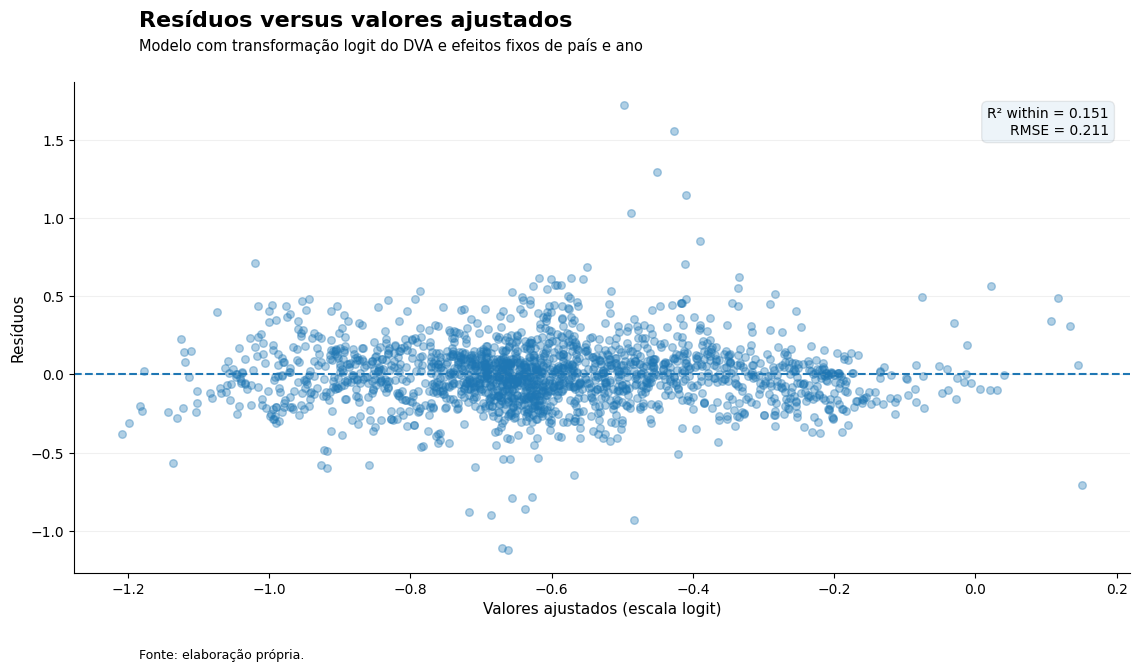

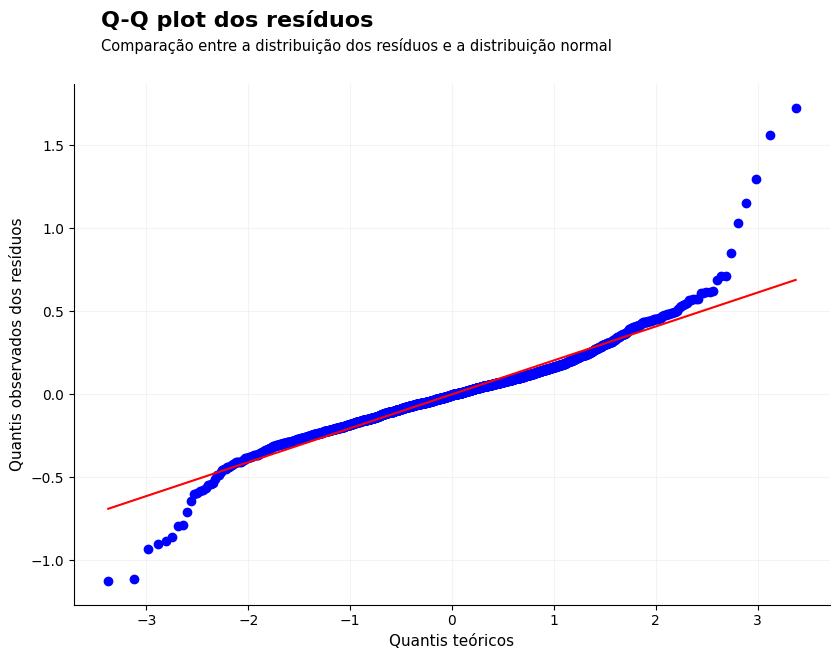

In [35]:
# ============================================================
# DIAGNÓSTICOS DO MODELO LOGIT COM EFEITOS FIXOS
# 1) Resíduos x valores ajustados
# 2) Q-Q plot dos resíduos
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Valores ajustados e resíduos
fitted = resultado_logit_fe.fitted_values.iloc[:, 0]
resid = resultado_logit_fe.resids

# RMSE na escala do logit
rmse = np.sqrt(np.mean(resid**2))

# ----------------------------
# GRÁFICO 1: RESÍDUOS x AJUSTADOS
# ----------------------------

fig, ax = plt.subplots(figsize=(11.5, 6.8))

ax.scatter(
    fitted,
    resid,
    alpha=0.35,
    s=30
)

ax.axhline(
    y=0,
    linestyle='--',
    linewidth=1.5
)

ax.set_xlabel('Valores ajustados (escala logit)', fontsize=11)
ax.set_ylabel('Resíduos', fontsize=11)

fig.text(
    0.125, 0.95,
    'Resíduos versus valores ajustados',
    fontsize=16,
    fontweight='bold'
)

fig.text(
    0.125, 0.915,
    'Modelo com transformação logit do DVA e efeitos fixos de país e ano',
    fontsize=10.5
)

# Caixa com métricas
texto_metricas = (
    f"R² within = {resultado_logit_fe.rsquared_within:.3f}\n"
    f"RMSE = {rmse:.3f}"
)
ax.text(
    0.98, 0.95,
    texto_metricas,
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.4', alpha=0.08)
)

ax.grid(axis='y', alpha=0.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.text(
    0.125, 0.02,
    'Fonte: elaboração própria.',
    fontsize=9
)

plt.tight_layout(rect=[0, 0.06, 1, 0.89])
plt.show()


# ----------------------------
# GRÁFICO 2: Q-Q PLOT DOS RESÍDUOS
# ----------------------------

fig, ax = plt.subplots(figsize=(8.5, 7))

stats.probplot(
    resid,
    dist="norm",
    plot=ax
)

ax.set_title('')

fig.text(
    0.125, 0.95,
    'Q-Q plot dos resíduos',
    fontsize=16,
    fontweight='bold'
)

fig.text(
    0.125, 0.915,
    'Comparação entre a distribuição dos resíduos e a distribuição normal',
    fontsize=10.5
)

ax.set_xlabel('Quantis teóricos', fontsize=11)
ax.set_ylabel('Quantis observados dos resíduos', fontsize=11)

ax.grid(alpha=0.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.04, 1, 0.89])
plt.show()

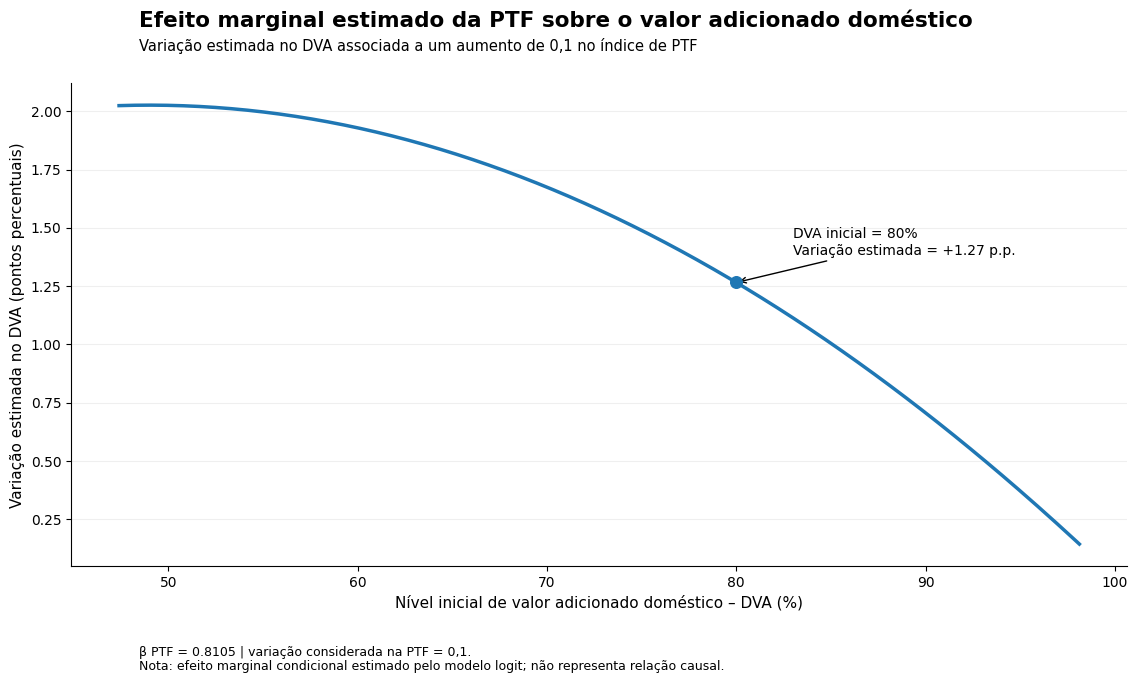

In [36]:
# ============================================================
# GRÁFICO — EFEITO MARGINAL ESTIMADO DA PTF SOBRE O DVA
# Modelo logit com efeitos fixos de país e ano
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Coeficiente estimado da PTF
# ------------------------------------------------------------

beta_ptf = resultado_logit_fe.params['PTF']

# Variação da PTF utilizada para facilitar a interpretação
delta_ptf = 0.1


# ------------------------------------------------------------
# 2. Intervalo observado do DVA na amostra
# ------------------------------------------------------------

dva_inicial = np.linspace(
    reg_logit['DVA_prop'].min(),
    reg_logit['DVA_prop'].max(),
    300
)


# ------------------------------------------------------------
# 3. Calcula o efeito de +0,1 na PTF
# ------------------------------------------------------------

# Transforma o DVA inicial para a escala logit
logit_inicial = np.log(
    dva_inicial / (1 - dva_inicial)
)

# Acrescenta o efeito correspondente ao aumento de 0,1 na PTF
logit_novo = (
    logit_inicial +
    beta_ptf * delta_ptf
)

# Retorna para a escala original do DVA
dva_novo = 1 / (
    1 + np.exp(-logit_novo)
)

# Variação do DVA em pontos percentuais
efeito_pp = (
    dva_novo - dva_inicial
) * 100


# ------------------------------------------------------------
# 4. Exemplo específico: DVA inicial = 80%
# ------------------------------------------------------------

dva_exemplo = 0.80

logit_exemplo = np.log(
    dva_exemplo / (1 - dva_exemplo)
)

logit_novo_exemplo = (
    logit_exemplo +
    beta_ptf * delta_ptf
)

dva_novo_exemplo = 1 / (
    1 + np.exp(-logit_novo_exemplo)
)

efeito_exemplo = (
    dva_novo_exemplo - dva_exemplo
) * 100


# ------------------------------------------------------------
# 5. Construção do gráfico
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11.5, 6.8))

ax.plot(
    dva_inicial * 100,
    efeito_pp,
    linewidth=2.5
)

# Ponto de referência em DVA = 80%
ax.scatter(
    80,
    efeito_exemplo,
    s=70,
    zorder=5
)

ax.annotate(
    f'DVA inicial = 80%\n'
    f'Variação estimada = +{efeito_exemplo:.2f} p.p.',
    xy=(80, efeito_exemplo),
    xytext=(83, efeito_exemplo + 0.12),
    fontsize=10,
    arrowprops=dict(
        arrowstyle='->',
        lw=1
    )
)


# ------------------------------------------------------------
# 6. Eixos
# ------------------------------------------------------------

ax.set_xlabel(
    'Nível inicial de valor adicionado doméstico – DVA (%)',
    fontsize=11
)

ax.set_ylabel(
    'Variação estimada no DVA (pontos percentuais)',
    fontsize=11
)


# ------------------------------------------------------------
# 7. Título e subtítulo
# ------------------------------------------------------------

fig.text(
    0.125,
    0.95,
    'Efeito marginal estimado da PTF sobre o valor adicionado doméstico',
    fontsize=15.5,
    fontweight='bold'
)

fig.text(
    0.125,
    0.915,
    'Variação estimada no DVA associada a um aumento de 0,1 no índice de PTF',
    fontsize=10.5
)


# ------------------------------------------------------------
# 8. Formatação
# ------------------------------------------------------------

ax.grid(
    axis='y',
    alpha=0.20
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ------------------------------------------------------------
# 9. Informações e nota
# ------------------------------------------------------------

fig.text(
    0.125,
    0.025,
    f'β PTF = {beta_ptf:.4f} | variação considerada na PTF = 0,1.',
    fontsize=9
)

fig.text(
    0.125,
    0.005,
    'Nota: efeito marginal condicional estimado pelo modelo logit; '
    'não representa relação causal.',
    fontsize=9
)


# ------------------------------------------------------------
# 10. Ajuste final
# ------------------------------------------------------------

plt.tight_layout(
    rect=[0, 0.07, 1, 0.89]
)

plt.show()

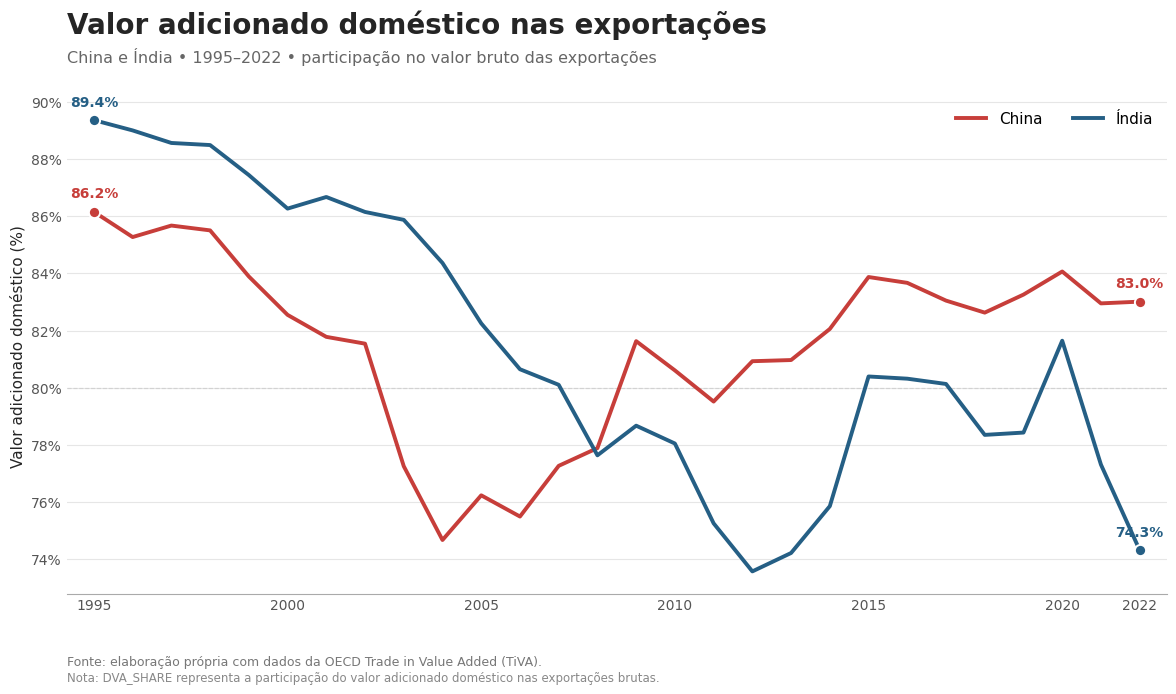

In [37]:
# ============================================================
# CÉLULA 6 — FIGURA 1
# DVA NAS EXPORTAÇÕES — CHINA x ÍNDIA
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Dados
comp = painel[
    painel["country"].isin(["CHN", "IND"])
].copy()

china = comp[comp["country"] == "CHN"]
india = comp[comp["country"] == "IND"]

# Paleta
COR_CHINA = "#C73E3A"
COR_INDIA = "#255F85"
COR_TEXTO = "#252525"
COR_GRADE = "#D9D9D9"

fig, ax = plt.subplots(figsize=(12.5, 6.8))

# Linhas
ax.plot(
    china["year"], china["DVA_SHARE"],
    color=COR_CHINA,
    linewidth=2.8,
    label="China",
    zorder=3
)

ax.plot(
    india["year"], india["DVA_SHARE"],
    color=COR_INDIA,
    linewidth=2.8,
    label="Índia",
    zorder=3
)

# Destaque dos pontos inicial/final
for dados, cor in [(china, COR_CHINA), (india, COR_INDIA)]:
    for _, p in dados.iloc[[0, -1]].iterrows():

        ax.scatter(
            p["year"],
            p["DVA_SHARE"],
            s=65,
            color=cor,
            edgecolor="white",
            linewidth=1.4,
            zorder=5
        )

        ax.annotate(
            f'{p["DVA_SHARE"]:.1f}%',
            (p["year"], p["DVA_SHARE"]),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=10,
            fontweight="bold",
            color=cor
        )

# Linha de referência em 80%
ax.axhline(
    80,
    linewidth=0.8,
    linestyle="--",
    color="#999999",
    alpha=.55,
    zorder=1
)

# Título
fig.text(
    0.08, 0.955,
    "Valor adicionado doméstico nas exportações",
    fontsize=20,
    fontweight="bold",
    color=COR_TEXTO
)

fig.text(
    0.08, 0.912,
    "China e Índia • 1995–2022 • participação no valor bruto das exportações",
    fontsize=11.5,
    color="#666666"
)

# Eixos
ax.set_ylabel(
    "Valor adicionado doméstico (%)",
    fontsize=11,
    color=COR_TEXTO
)

ax.set_xlabel("")

ax.set_xlim(1994.3, 2022.7)

ax.set_xticks(
    [1995, 2000, 2005, 2010, 2015, 2020, 2022]
)

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=100, decimals=0)
)

# Grade apenas horizontal
ax.grid(
    axis="y",
    color=COR_GRADE,
    linewidth=.8,
    alpha=.65
)

ax.grid(axis="x", visible=False)

# Remover bordas desnecessárias
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.spines["bottom"].set_color("#AAAAAA")

ax.tick_params(
    axis="both",
    labelsize=10,
    colors="#555555",
    length=0
)

# Legenda
ax.legend(
    frameon=False,
    ncol=2,
    loc="upper right",
    fontsize=11
)

# Fonte
fig.text(
    0.08, 0.025,
    "Fonte: elaboração própria com dados da OECD Trade in Value Added (TiVA).",
    fontsize=9,
    color="#777777"
)

fig.text(
    0.08, 0.002,
    "Nota: DVA_SHARE representa a participação do valor adicionado doméstico nas exportações brutas.",
    fontsize=8.5,
    color="#888888"
)

plt.subplots_adjust(
    left=.08,
    right=.96,
    top=.86,
    bottom=.13
)

# Salvar em alta resolução
plt.savefig(
    "/content/Figura_1_DVA_China_India.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

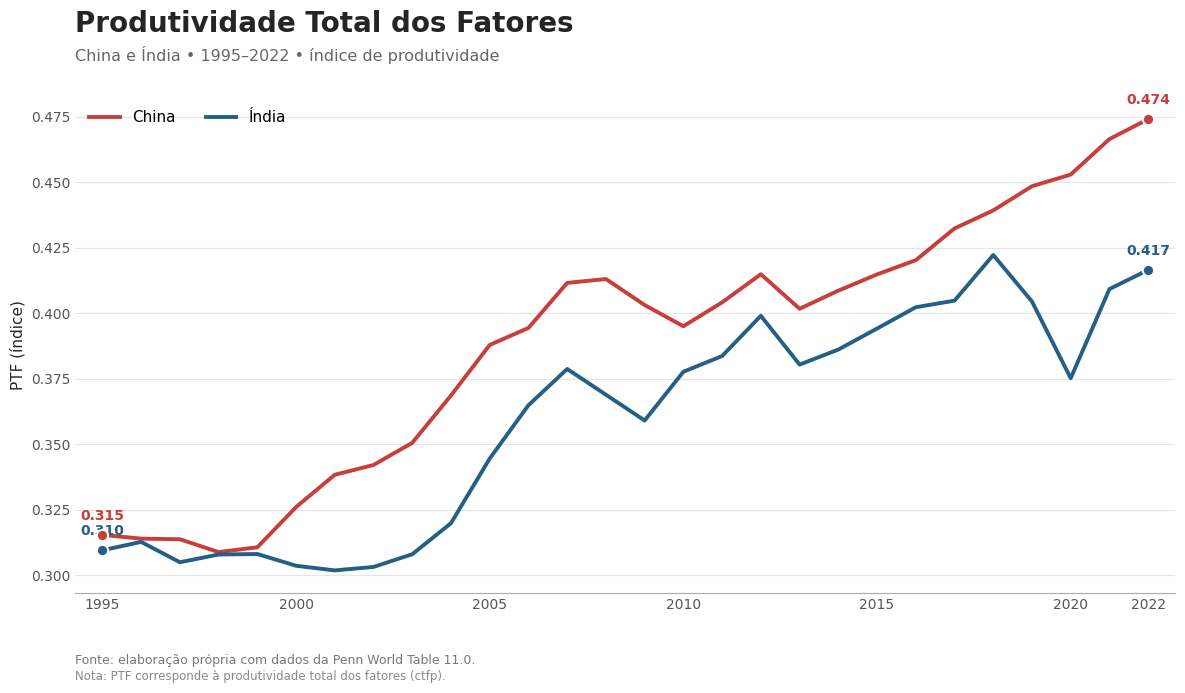

In [38]:
# ============================================================
# CÉLULA 7 — FIGURA 2
# PRODUTIVIDADE TOTAL DOS FATORES — CHINA x ÍNDIA
# ============================================================

china = painel[painel["country"] == "CHN"].dropna(subset=["PTF"])
india = painel[painel["country"] == "IND"].dropna(subset=["PTF"])

fig, ax = plt.subplots(figsize=(12.5, 6.8))

# Linhas
ax.plot(
    china["year"], china["PTF"],
    color=COR_CHINA,
    linewidth=2.8,
    label="China",
    zorder=3
)

ax.plot(
    india["year"], india["PTF"],
    color=COR_INDIA,
    linewidth=2.8,
    label="Índia",
    zorder=3
)

# Pontos inicial e final
for dados, cor in [(china, COR_CHINA), (india, COR_INDIA)]:

    for _, p in dados.iloc[[0, -1]].iterrows():

        ax.scatter(
            p["year"], p["PTF"],
            s=65,
            color=cor,
            edgecolor="white",
            linewidth=1.4,
            zorder=5
        )

        ax.annotate(
            f'{p["PTF"]:.3f}',
            (p["year"], p["PTF"]),
            xytext=(0, 11),
            textcoords="offset points",
            ha="center",
            fontsize=10,
            fontweight="bold",
            color=cor
        )

# Títulos
fig.text(
    0.08, 0.955,
    "Produtividade Total dos Fatores",
    fontsize=20,
    fontweight="bold",
    color=COR_TEXTO
)

fig.text(
    0.08, 0.912,
    "China e Índia • 1995–2022 • índice de produtividade",
    fontsize=11.5,
    color="#666666"
)

# Eixos
ax.set_ylabel(
    "PTF (índice)",
    fontsize=11,
    color=COR_TEXTO
)

ax.set_xlabel("")

ax.set_xlim(1994.3, 2022.7)

ax.set_xticks(
    [1995, 2000, 2005, 2010, 2015, 2020, 2022]
)

# Grade
ax.grid(
    axis="y",
    color=COR_GRADE,
    linewidth=.8,
    alpha=.65
)

ax.grid(axis="x", visible=False)

# Bordas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#AAAAAA")

ax.tick_params(
    axis="both",
    labelsize=10,
    colors="#555555",
    length=0
)

# Legenda
ax.legend(
    frameon=False,
    ncol=2,
    loc="upper left",
    fontsize=11
)

# Fonte e nota
fig.text(
    0.08, 0.025,
    "Fonte: elaboração própria com dados da Penn World Table 11.0.",
    fontsize=9,
    color="#777777"
)

fig.text(
    0.08, 0.002,
    "Nota: PTF corresponde à produtividade total dos fatores (ctfp).",
    fontsize=8.5,
    color="#888888"
)

plt.subplots_adjust(
    left=.08,
    right=.96,
    top=.86,
    bottom=.13
)

plt.savefig(
    "/content/Figura_2_PTF_China_India.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

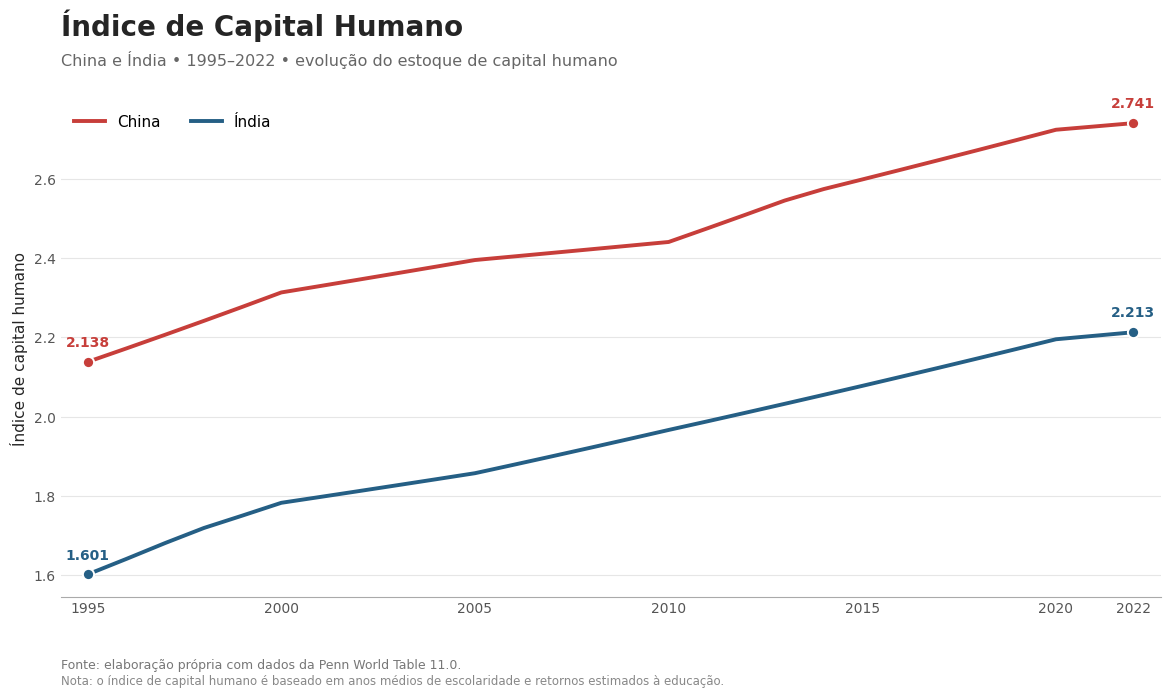

In [39]:
# ============================================================
# CÉLULA 8 — FIGURA 3
# CAPITAL HUMANO — CHINA x ÍNDIA
# ============================================================

china = painel[painel["country"] == "CHN"].dropna(subset=["HumanCapital"])
india = painel[painel["country"] == "IND"].dropna(subset=["HumanCapital"])

fig, ax = plt.subplots(figsize=(12.5, 6.8))

# Linhas
ax.plot(
    china["year"], china["HumanCapital"],
    color=COR_CHINA,
    linewidth=2.8,
    label="China",
    zorder=3
)

ax.plot(
    india["year"], india["HumanCapital"],
    color=COR_INDIA,
    linewidth=2.8,
    label="Índia",
    zorder=3
)

# Pontos inicial e final
for dados, cor in [(china, COR_CHINA), (india, COR_INDIA)]:

    for _, p in dados.iloc[[0, -1]].iterrows():

        ax.scatter(
            p["year"], p["HumanCapital"],
            s=65,
            color=cor,
            edgecolor="white",
            linewidth=1.4,
            zorder=5
        )

        ax.annotate(
            f'{p["HumanCapital"]:.3f}',
            (p["year"], p["HumanCapital"]),
            xytext=(0, 11),
            textcoords="offset points",
            ha="center",
            fontsize=10,
            fontweight="bold",
            color=cor
        )

# Títulos
fig.text(
    0.08, 0.955,
    "Índice de Capital Humano",
    fontsize=20,
    fontweight="bold",
    color=COR_TEXTO
)

fig.text(
    0.08, 0.912,
    "China e Índia • 1995–2022 • evolução do estoque de capital humano",
    fontsize=11.5,
    color="#666666"
)

# Eixos
ax.set_ylabel(
    "Índice de capital humano",
    fontsize=11,
    color=COR_TEXTO
)

ax.set_xlabel("")

ax.set_xlim(1994.3, 2022.7)

ax.set_xticks(
    [1995, 2000, 2005, 2010, 2015, 2020, 2022]
)

# Grade
ax.grid(
    axis="y",
    color=COR_GRADE,
    linewidth=.8,
    alpha=.65
)

ax.grid(axis="x", visible=False)

# Bordas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#AAAAAA")

ax.tick_params(
    axis="both",
    labelsize=10,
    colors="#555555",
    length=0
)

# Legenda
ax.legend(
    frameon=False,
    ncol=2,
    loc="upper left",
    fontsize=11
)

# Fonte e nota
fig.text(
    0.08, 0.025,
    "Fonte: elaboração própria com dados da Penn World Table 11.0.",
    fontsize=9,
    color="#777777"
)

fig.text(
    0.08, 0.002,
    "Nota: o índice de capital humano é baseado em anos médios de escolaridade e retornos estimados à educação.",
    fontsize=8.5,
    color="#888888"
)

plt.subplots_adjust(
    left=.08,
    right=.96,
    top=.86,
    bottom=.13
)

plt.savefig(
    "/content/Figura_3_Capital_Humano_China_India.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

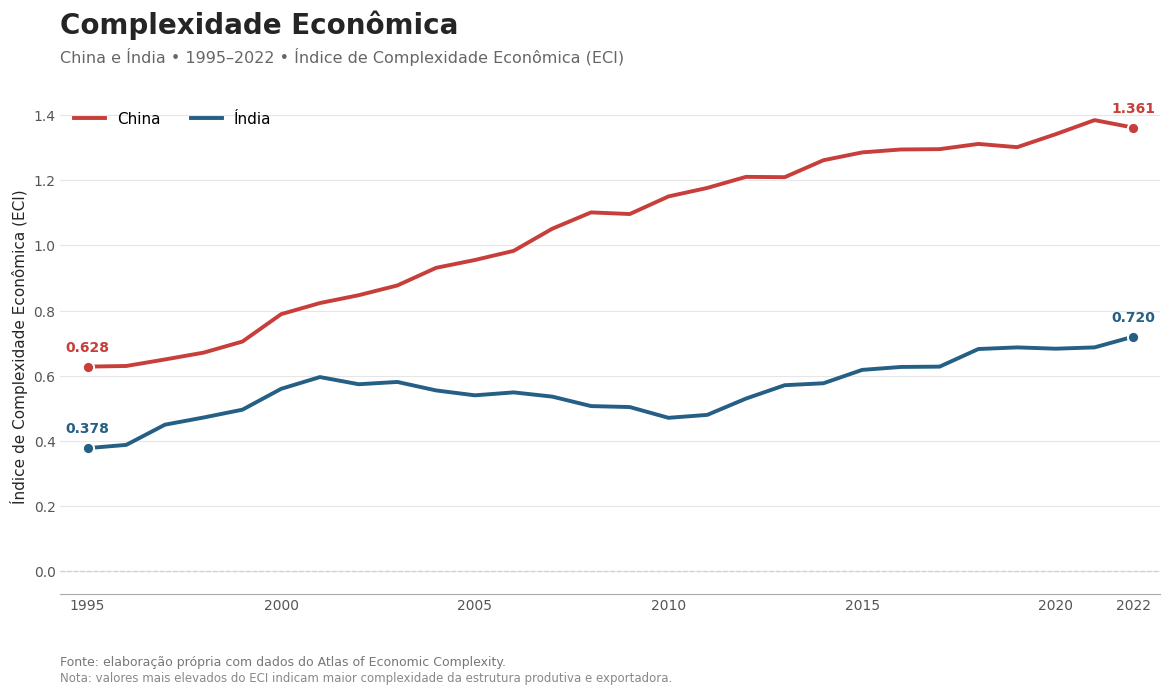

In [40]:
# ============================================================
# CÉLULA 9 — FIGURA 4
# COMPLEXIDADE ECONÔMICA (ECI) — CHINA x ÍNDIA
# ============================================================

china = painel[painel["country"] == "CHN"].dropna(subset=["ECI"])
india = painel[painel["country"] == "IND"].dropna(subset=["ECI"])

fig, ax = plt.subplots(figsize=(12.5, 6.8))

# Linhas
ax.plot(
    china["year"], china["ECI"],
    color=COR_CHINA, linewidth=2.8,
    label="China", zorder=3
)

ax.plot(
    india["year"], india["ECI"],
    color=COR_INDIA, linewidth=2.8,
    label="Índia", zorder=3
)

# Linha de referência: ECI = 0
ax.axhline(
    0,
    color="#999999",
    linestyle="--",
    linewidth=0.9,
    alpha=0.6,
    zorder=1
)

# Pontos inicial e final
for dados, cor in [(china, COR_CHINA), (india, COR_INDIA)]:

    for _, p in dados.iloc[[0, -1]].iterrows():

        ax.scatter(
            p["year"], p["ECI"],
            s=65,
            color=cor,
            edgecolor="white",
            linewidth=1.4,
            zorder=5
        )

        ax.annotate(
            f'{p["ECI"]:.3f}',
            (p["year"], p["ECI"]),
            xytext=(0, 11),
            textcoords="offset points",
            ha="center",
            fontsize=10,
            fontweight="bold",
            color=cor
        )

# Títulos
fig.text(
    0.08, 0.955,
    "Complexidade Econômica",
    fontsize=20,
    fontweight="bold",
    color=COR_TEXTO
)

fig.text(
    0.08, 0.912,
    "China e Índia • 1995–2022 • Índice de Complexidade Econômica (ECI)",
    fontsize=11.5,
    color="#666666"
)

# Eixos
ax.set_ylabel(
    "Índice de Complexidade Econômica (ECI)",
    fontsize=11,
    color=COR_TEXTO
)

ax.set_xlabel("")
ax.set_xlim(1994.3, 2022.7)

ax.set_xticks(
    [1995, 2000, 2005, 2010, 2015, 2020, 2022]
)

# Grade
ax.grid(
    axis="y",
    color=COR_GRADE,
    linewidth=.8,
    alpha=.65
)
ax.grid(axis="x", visible=False)

# Bordas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#AAAAAA")

ax.tick_params(
    axis="both",
    labelsize=10,
    colors="#555555",
    length=0
)

# Legenda
ax.legend(
    frameon=False,
    ncol=2,
    loc="upper left",
    fontsize=11
)

# Fonte
fig.text(
    0.08, 0.025,
    "Fonte: elaboração própria com dados do Atlas of Economic Complexity.",
    fontsize=9,
    color="#777777"
)

fig.text(
    0.08, 0.002,
    "Nota: valores mais elevados do ECI indicam maior complexidade da estrutura produtiva e exportadora.",
    fontsize=8.5,
    color="#888888"
)

plt.subplots_adjust(
    left=.08,
    right=.96,
    top=.86,
    bottom=.13
)

plt.savefig(
    "/content/Figura_4_ECI_China_India.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

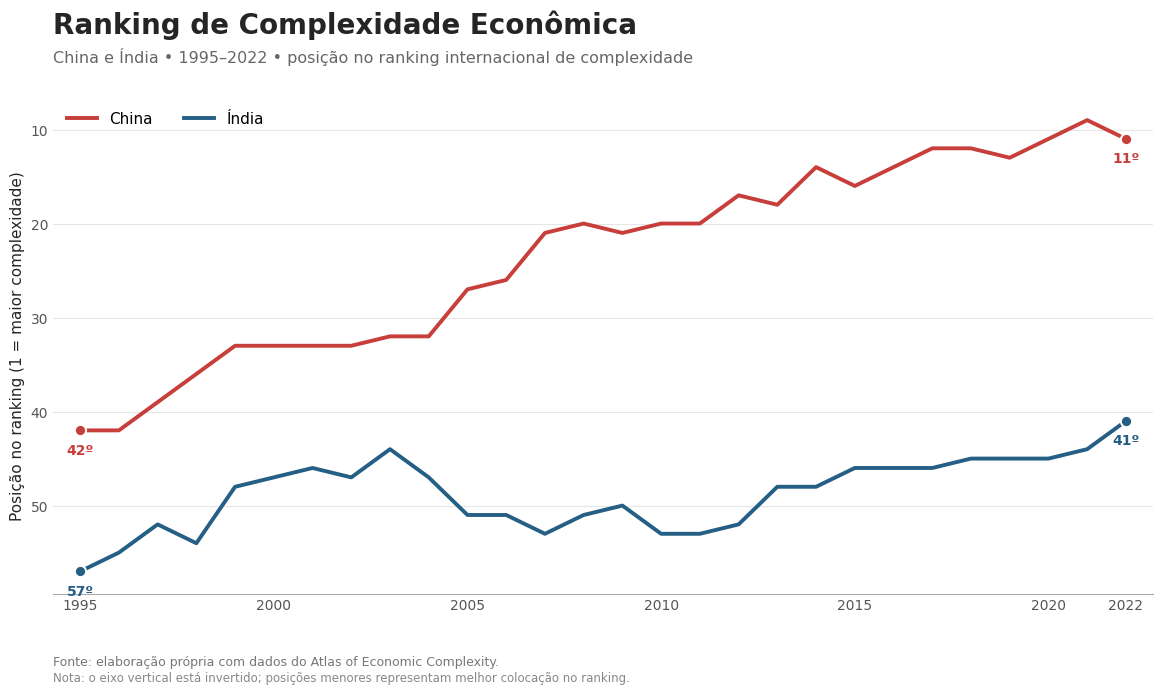

In [41]:
# ============================================================
# CÉLULA 10 — FIGURA 5
# RANKING DE COMPLEXIDADE ECONÔMICA — CHINA x ÍNDIA
# ============================================================

china = painel[painel["country"] == "CHN"].dropna(subset=["ECI_rank"])
india = painel[painel["country"] == "IND"].dropna(subset=["ECI_rank"])

fig, ax = plt.subplots(figsize=(12.5, 6.8))

# Linhas
ax.plot(
    china["year"], china["ECI_rank"],
    color=COR_CHINA,
    linewidth=2.8,
    label="China",
    zorder=3
)

ax.plot(
    india["year"], india["ECI_rank"],
    color=COR_INDIA,
    linewidth=2.8,
    label="Índia",
    zorder=3
)

# Pontos inicial e final
for dados, cor in [(china, COR_CHINA), (india, COR_INDIA)]:

    for _, p in dados.iloc[[0, -1]].iterrows():

        ax.scatter(
            p["year"], p["ECI_rank"],
            s=65,
            color=cor,
            edgecolor="white",
            linewidth=1.4,
            zorder=5
        )

        ax.annotate(
            f'{int(p["ECI_rank"])}º',
            (p["year"], p["ECI_rank"]),
            xytext=(0, -17),
            textcoords="offset points",
            ha="center",
            fontsize=10,
            fontweight="bold",
            color=cor
        )

# IMPORTANTE: posição 1 deve ficar no topo
ax.invert_yaxis()

# Títulos
fig.text(
    0.08, 0.955,
    "Ranking de Complexidade Econômica",
    fontsize=20,
    fontweight="bold",
    color=COR_TEXTO
)

fig.text(
    0.08, 0.912,
    "China e Índia • 1995–2022 • posição no ranking internacional de complexidade",
    fontsize=11.5,
    color="#666666"
)

# Eixos
ax.set_ylabel(
    "Posição no ranking (1 = maior complexidade)",
    fontsize=11,
    color=COR_TEXTO
)

ax.set_xlabel("")
ax.set_xlim(1994.3, 2022.7)

ax.set_xticks(
    [1995, 2000, 2005, 2010, 2015, 2020, 2022]
)

# Grade
ax.grid(
    axis="y",
    color=COR_GRADE,
    linewidth=.8,
    alpha=.65
)

ax.grid(axis="x", visible=False)

# Bordas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#AAAAAA")

ax.tick_params(
    axis="both",
    labelsize=10,
    colors="#555555",
    length=0
)

# Legenda
ax.legend(
    frameon=False,
    ncol=2,
    loc="upper left",
    fontsize=11
)

# Fonte e nota
fig.text(
    0.08, 0.025,
    "Fonte: elaboração própria com dados do Atlas of Economic Complexity.",
    fontsize=9,
    color="#777777"
)

fig.text(
    0.08, 0.002,
    "Nota: o eixo vertical está invertido; posições menores representam melhor colocação no ranking.",
    fontsize=8.5,
    color="#888888"
)

plt.subplots_adjust(
    left=.08,
    right=.96,
    top=.86,
    bottom=.13
)

plt.savefig(
    "/content/Figura_5_Ranking_ECI_China_India.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [42]:
# ============================================================
# CÉLULA 11 — GLOBAL MARKET SHARE
# World Bank API
# ============================================================

import requests

INDICADOR = "NE.EXP.GNFS.CD"
PAISES = ["CHN", "IND", "WLD"]

def baixar_world_bank(codigo):
    url = (
        f"https://api.worldbank.org/v2/country/{codigo}"
        f"/indicator/{INDICADOR}"
        "?format=json&per_page=100"
    )

    resposta = requests.get(url, timeout=30)
    resposta.raise_for_status()

    dados = resposta.json()[1]

    return pd.DataFrame({
        "year": [int(x["date"]) for x in dados],
        codigo: [x["value"] for x in dados]
    })

# Download
wb_china = baixar_world_bank("CHN")
wb_india = baixar_world_bank("IND")
wb_world = baixar_world_bank("WLD")

# Merge
market = (
    wb_china
    .merge(wb_india, on="year", validate="one_to_one")
    .merge(wb_world, on="year", validate="one_to_one")
)

# Período do TCC
market = market.query("1995 <= year <= 2022").copy()

# Market share = exportações do país / exportações mundiais
market["China"] = market["CHN"] / market["WLD"] * 100
market["India"] = market["IND"] / market["WLD"] * 100

market = market[
    ["year", "China", "India"]
].sort_values("year")

print("=" * 70)
print("GLOBAL MARKET SHARE")
print("=" * 70)

print("Período:", market["year"].min(), "-", market["year"].max())
print("Observações:", len(market))

anos = [1995, 2000, 2005, 2010, 2015, 2020, 2022]

print("\nAnos selecionados:")
print(
    market[market["year"].isin(anos)]
    .round(2)
    .to_string(index=False)
)

GLOBAL MARKET SHARE
Período: 1995 - 2022
Observações: 28

Anos selecionados:
 year  China  India
 1995   2.04   0.60
 2000   3.18   0.77
 2005   5.98   1.24
 2010   8.71   1.98
 2015  11.10   1.96
 2020  12.18   2.22
 2022  11.72   2.47


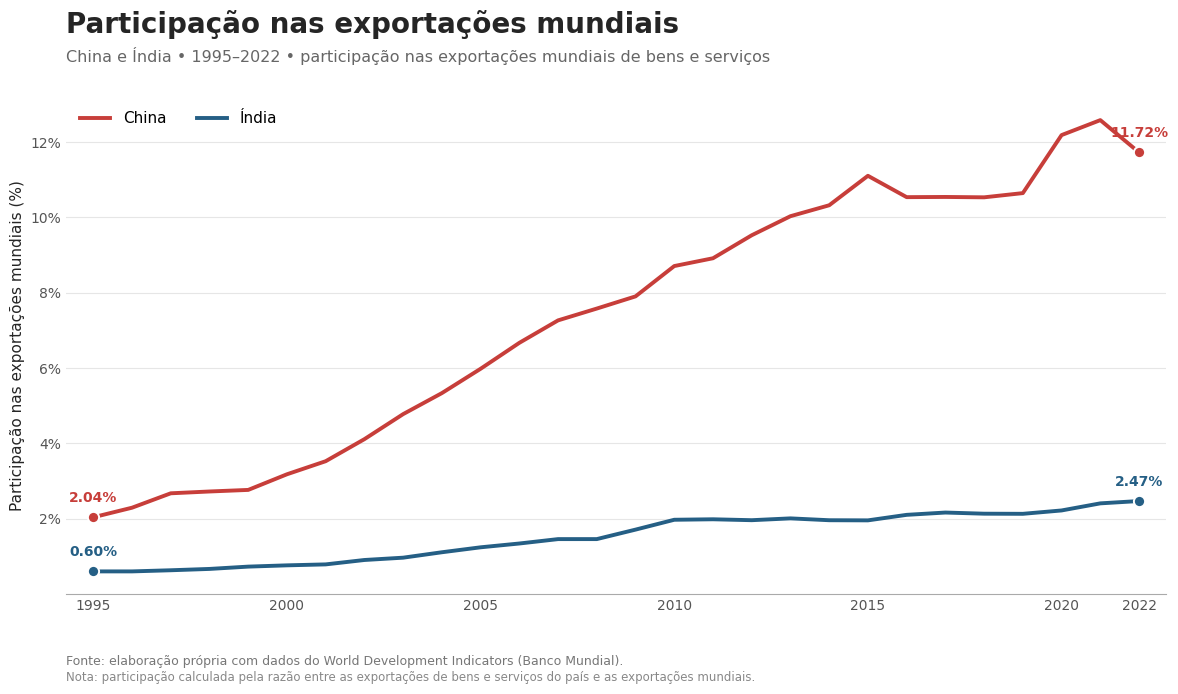

In [43]:
# ============================================================
# CÉLULA 12 — FIGURA 6
# GLOBAL MARKET SHARE — CHINA x ÍNDIA
# ============================================================

fig, ax = plt.subplots(figsize=(12.5, 6.8))

# Linhas
ax.plot(
    market["year"], market["China"],
    color=COR_CHINA,
    linewidth=2.8,
    label="China",
    zorder=3
)

ax.plot(
    market["year"], market["India"],
    color=COR_INDIA,
    linewidth=2.8,
    label="Índia",
    zorder=3
)

# Pontos inicial e final
for coluna, cor in [
    ("China", COR_CHINA),
    ("India", COR_INDIA)
]:
    dados = market.dropna(subset=[coluna])

    for _, p in dados.iloc[[0, -1]].iterrows():

        ax.scatter(
            p["year"], p[coluna],
            s=65,
            color=cor,
            edgecolor="white",
            linewidth=1.4,
            zorder=5
        )

        ax.annotate(
            f'{p[coluna]:.2f}%',
            (p["year"], p[coluna]),
            xytext=(0, 11),
            textcoords="offset points",
            ha="center",
            fontsize=10,
            fontweight="bold",
            color=cor
        )

# Títulos
fig.text(
    0.08, 0.955,
    "Participação nas exportações mundiais",
    fontsize=20,
    fontweight="bold",
    color=COR_TEXTO
)

fig.text(
    0.08, 0.912,
    "China e Índia • 1995–2022 • participação nas exportações mundiais de bens e serviços",
    fontsize=11.5,
    color="#666666"
)

# Eixos
ax.set_ylabel(
    "Participação nas exportações mundiais (%)",
    fontsize=11,
    color=COR_TEXTO
)

ax.set_xlabel("")
ax.set_xlim(1994.3, 2022.7)

ax.set_xticks(
    [1995, 2000, 2005, 2010, 2015, 2020, 2022]
)

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=100, decimals=0)
)

# Grade
ax.grid(
    axis="y",
    color=COR_GRADE,
    linewidth=.8,
    alpha=.65
)

ax.grid(axis="x", visible=False)

# Bordas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#AAAAAA")

ax.tick_params(
    axis="both",
    labelsize=10,
    colors="#555555",
    length=0
)

# Legenda
ax.legend(
    frameon=False,
    ncol=2,
    loc="upper left",
    fontsize=11
)

# Fonte
fig.text(
    0.08, 0.025,
    "Fonte: elaboração própria com dados do World Development Indicators (Banco Mundial).",
    fontsize=9,
    color="#777777"
)

fig.text(
    0.08, 0.002,
    "Nota: participação calculada pela razão entre as exportações de bens e serviços do país e as exportações mundiais.",
    fontsize=8.5,
    color="#888888"
)

plt.subplots_adjust(
    left=.08,
    right=.96,
    top=.86,
    bottom=.13
)

plt.savefig(
    "/content/Figura_6_Market_Share_China_India.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [44]:
# ============================================================
# CÉLULA 13 — TABELA-SÍNTESE
# CHINA x ÍNDIA
# ============================================================

anos_selecionados = [1995, 2000, 2005, 2010, 2015, 2020, 2022]

# Painel China e Índia
sintese = painel[
    painel["country"].isin(["CHN", "IND"]) &
    painel["year"].isin(anos_selecionados)
][
    ["country", "year", "DVA_SHARE", "PTF", "HumanCapital", "ECI"]
].copy()

# Adicionar market share
market_long = market.melt(
    id_vars="year",
    value_vars=["China", "India"],
    var_name="pais_market",
    value_name="MarketShare"
)

market_long["country"] = market_long["pais_market"].map({
    "China": "CHN",
    "India": "IND"
})

sintese = sintese.merge(
    market_long[["country", "year", "MarketShare"]],
    on=["country", "year"],
    how="left",
    validate="one_to_one"
)

sintese["País"] = sintese["country"].map({
    "CHN": "China",
    "IND": "Índia"
})

sintese = sintese[
    ["País", "year", "DVA_SHARE", "PTF",
     "HumanCapital", "ECI", "MarketShare"]
].rename(columns={
    "year": "Ano",
    "DVA_SHARE": "DVA (%)",
    "HumanCapital": "Capital Humano",
    "MarketShare": "Market Share (%)"
})

# Arredondamento apenas para apresentação
tabela_sintese = sintese.copy()

tabela_sintese["DVA (%)"] = tabela_sintese["DVA (%)"].round(2)
tabela_sintese["PTF"] = tabela_sintese["PTF"].round(3)
tabela_sintese["Capital Humano"] = tabela_sintese["Capital Humano"].round(3)
tabela_sintese["ECI"] = tabela_sintese["ECI"].round(3)
tabela_sintese["Market Share (%)"] = tabela_sintese["Market Share (%)"].round(2)

print("=" * 85)
print("SÍNTESE DOS INDICADORES — CHINA E ÍNDIA")
print("=" * 85)

display(tabela_sintese)

SÍNTESE DOS INDICADORES — CHINA E ÍNDIA


,País,Ano,DVA (%),PTF,Capital Humano,ECI,Market Share (%)
0,China,1995,86.16,0.315,2.138,0.628,2.04
1,China,2000,82.55,0.326,2.314,0.789,3.18
2,China,2005,76.24,0.388,2.395,0.955,5.98
3,China,2010,80.61,0.395,2.441,1.150,8.71
4,China,2015,83.87,0.415,2.599,1.285,11.10
5,China,2020,84.07,0.453,2.725,1.341,12.18
6,China,2022,83.01,0.474,2.741,1.361,11.72
7,Índia,1995,89.36,0.310,1.601,0.378,0.60
8,Índia,2000,86.27,0.304,1.782,0.560,0.77
9,Índia,2005,82.25,0.345,1.857,0.540,1.24


In [45]:
# ============================================================
# CÉLULA 14 — ESTATÍSTICAS DESCRITIVAS
# AMOSTRA ECONOMÉTRICA INTERNACIONAL
# ============================================================

variaveis = ["DVA_SHARE", "PTF", "HumanCapital", "ECI"]

descritivas = (
    reg[variaveis]
    .describe()
    .T
    [["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
)

descritivas.columns = [
    "N", "Média", "Desvio-padrão",
    "Mínimo", "25%", "Mediana", "75%", "Máximo"
]

descritivas.index = [
    "DVA (%)",
    "PTF",
    "Capital Humano",
    "ECI"
]

descritivas["N"] = descritivas["N"].astype(int)

display(
    descritivas.style
    .format({
        "N": "{:d}",
        "Média": "{:.3f}",
        "Desvio-padrão": "{:.3f}",
        "Mínimo": "{:.3f}",
        "25%": "{:.3f}",
        "Mediana": "{:.3f}",
        "75%": "{:.3f}",
        "Máximo": "{:.3f}"
    })
    .set_caption(
        "Estatísticas descritivas — amostra internacional, 1995–2022"
    )
)

print("\nObservações:", len(reg))
print("Países:", reg["country"].nunique())
print("Período:", reg["year"].min(), "-", reg["year"].max())

,N,Média,Desvio-padrão,Mínimo,25%,Mediana,75%,Máximo
DVA (%),1871,77.034,10.137,47.389,70.376,77.256,85.046,98.126
PTF,1871,0.727,0.237,0.113,0.553,0.720,0.898,1.637
Capital Humano,1871,2.857,0.619,1.215,2.483,2.984,3.325,3.941
ECI,1871,0.652,0.802,-2.901,0.348,0.798,1.203,2.100



Observações: 1871
Países: 67
Período: 1995 - 2022


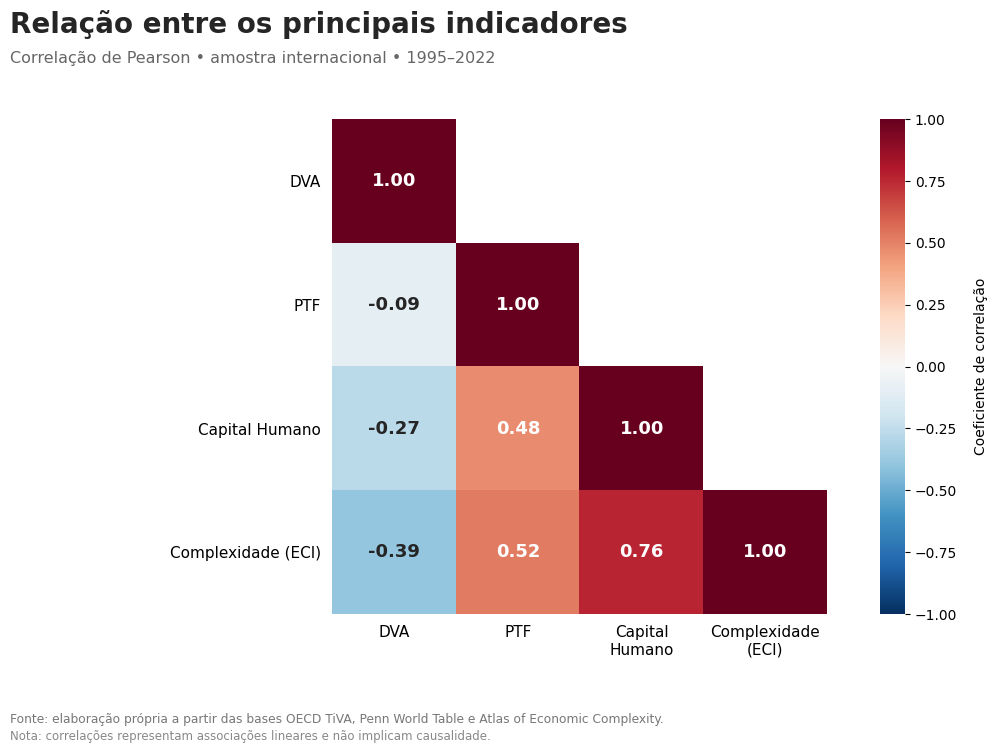

In [46]:
# ============================================================
# CÉLULA 15 — CORRELAÇÕES | VERSÃO FINAL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

vars_corr = ["DVA_SHARE", "PTF", "HumanCapital", "ECI"]

corr = reg[vars_corr].corr()

labels = [
    "DVA",
    "PTF",
    "Capital\nHumano",
    "Complexidade\n(ECI)"
]

# Triângulo inferior
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
dados_plot = np.ma.array(corr.values, mask=mask)

# Mais largo para evitar sobreposição
fig, ax = plt.subplots(figsize=(11.5, 7.5))

im = ax.imshow(
    dados_plot,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(4))
ax.set_yticks(range(4))

ax.set_xticklabels(
    labels,
    fontsize=11,
    ha="center"
)

ax.set_yticklabels(
    ["DVA", "PTF", "Capital Humano", "Complexidade (ECI)"],
    fontsize=11
)

# Valores
for i in range(4):
    for j in range(4):

        if j <= i:

            valor = corr.iloc[i, j]

            ax.text(
                j, i,
                f"{valor:.2f}",
                ha="center",
                va="center",
                fontsize=13,
                fontweight="bold",
                color="white" if abs(valor) > 0.45 else "#252525"
            )

# Limpeza visual
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0, pad=8)

# Títulos
fig.text(
    0.08, 0.955,
    "Relação entre os principais indicadores",
    fontsize=20,
    fontweight="bold",
    color="#252525"
)

fig.text(
    0.08, 0.915,
    "Correlação de Pearson • amostra internacional • 1995–2022",
    fontsize=11.5,
    color="#666666"
)

# Barra de correlação
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.07
)

cbar.set_label(
    "Coeficiente de correlação",
    fontsize=10,
    labelpad=12
)

cbar.outline.set_visible(False)

# Fonte
fig.text(
    0.08, 0.035,
    "Fonte: elaboração própria a partir das bases OECD TiVA, Penn World Table e Atlas of Economic Complexity.",
    fontsize=8.8,
    color="#777777"
)

fig.text(
    0.08, 0.012,
    "Nota: correlações representam associações lineares e não implicam causalidade.",
    fontsize=8.5,
    color="#888888"
)

plt.subplots_adjust(
    left=.20,
    right=.86,
    top=.84,
    bottom=.18
)

plt.savefig(
    "/content/Figura_7_Correlacoes.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

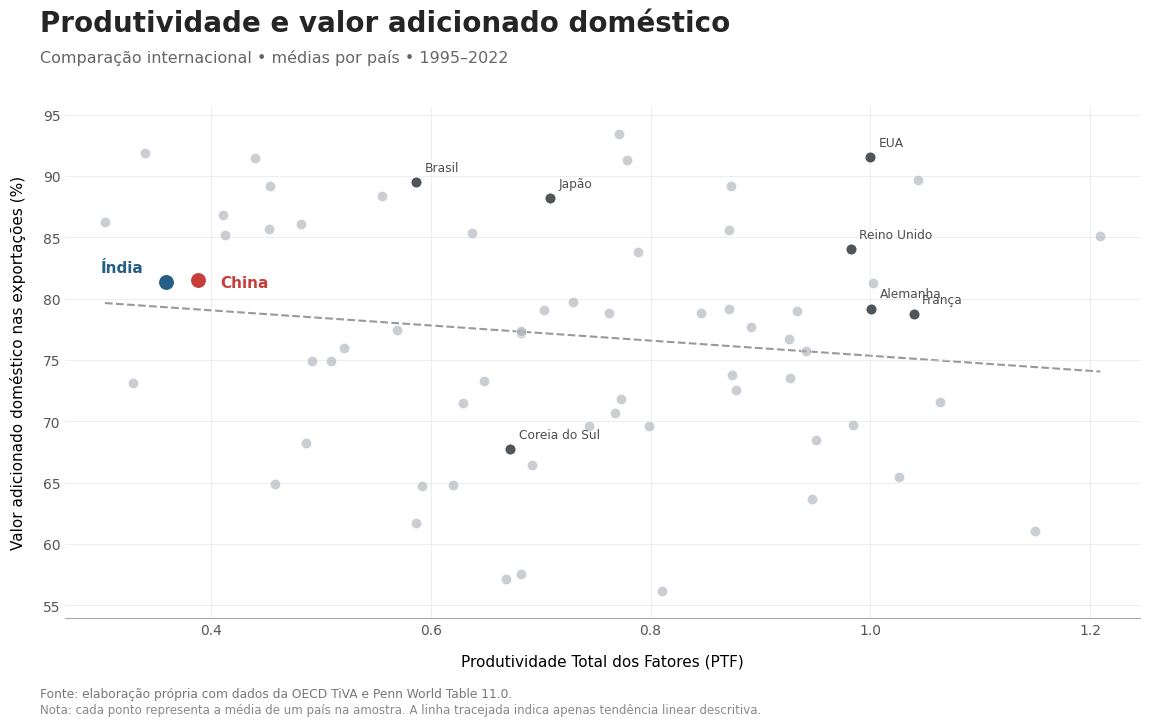

In [47]:
# ============================================================
# CÉLULA 16 — FIGURA 8
# DVA x PTF — COMPARAÇÃO INTERNACIONAL
# Cada ponto representa a média de um país, 1995–2022
# ============================================================

# ------------------------------------------------------------
# MÉDIA POR PAÍS
# ------------------------------------------------------------

pais_media = (
    reg.groupby("country", as_index=False)
       [["DVA_SHARE", "PTF"]]
       .mean()
)

fig, ax = plt.subplots(figsize=(12.5, 7.2))

# ------------------------------------------------------------
# DEMAIS PAÍSES
# ------------------------------------------------------------

outros = pais_media[
    ~pais_media["country"].isin(["CHN", "IND"])
]

ax.scatter(
    outros["PTF"],
    outros["DVA_SHARE"],
    s=55,
    color="#A7ADB3",
    alpha=0.60,
    edgecolor="white",
    linewidth=0.6,
    zorder=2
)

# ------------------------------------------------------------
# CHINA E ÍNDIA
# Rótulos posicionados em lados diferentes
# ------------------------------------------------------------

destaques = {
    "CHN": {
        "nome": "China",
        "cor": COR_CHINA,
        "offset": (16, -2),
        "ha": "left"
    },
    "IND": {
        "nome": "Índia",
        "cor": COR_INDIA,
        "offset": (-16, 10),
        "ha": "right"
    }
}

for codigo, info in destaques.items():

    p = pais_media[pais_media["country"] == codigo]

    if not p.empty:

        x_p = p["PTF"].iloc[0]
        y_p = p["DVA_SHARE"].iloc[0]

        ax.scatter(
            x_p,
            y_p,
            s=150,
            color=info["cor"],
            edgecolor="white",
            linewidth=1.5,
            zorder=5
        )

        ax.annotate(
            info["nome"],
            (x_p, y_p),
            xytext=info["offset"],
            textcoords="offset points",
            ha=info["ha"],
            va="center",
            fontsize=11,
            fontweight="bold",
            color=info["cor"],
            zorder=6
        )

# ------------------------------------------------------------
# PAÍSES INTERNACIONAIS SELECIONADOS
# ------------------------------------------------------------

selecionados = {
    "USA": "EUA",
    "DEU": "Alemanha",
    "JPN": "Japão",
    "KOR": "Coreia do Sul",
    "GBR": "Reino Unido",
    "FRA": "França",
    "BRA": "Brasil"
}

# Pequenos ajustes individuais para evitar colisões
offsets = {
    "USA": (6, 8),
    "DEU": (6, 8),
    "JPN": (6, 8),
    "KOR": (6, 8),
    "GBR": (6, 8),
    "FRA": (6, 8),
    "BRA": (6, 8)
}

for codigo, nome in selecionados.items():

    p = pais_media[pais_media["country"] == codigo]

    if not p.empty:

        x_p = p["PTF"].iloc[0]
        y_p = p["DVA_SHARE"].iloc[0]

        ax.scatter(
            x_p,
            y_p,
            s=65,
            color="#50555A",
            edgecolor="white",
            linewidth=0.8,
            zorder=4
        )

        ax.annotate(
            nome,
            (x_p, y_p),
            xytext=offsets[codigo],
            textcoords="offset points",
            fontsize=8.8,
            color="#4D4D4D",
            zorder=5
        )

# ------------------------------------------------------------
# LINHA DE TENDÊNCIA DESCRITIVA
# ------------------------------------------------------------

x = pais_media["PTF"].values
y = pais_media["DVA_SHARE"].values

coef = np.polyfit(x, y, 1)
linha = np.poly1d(coef)

x_linha = np.linspace(
    x.min(),
    x.max(),
    200
)

ax.plot(
    x_linha,
    linha(x_linha),
    color="#777777",
    linewidth=1.5,
    linestyle="--",
    alpha=0.75,
    zorder=1
)

# ------------------------------------------------------------
# TÍTULO E SUBTÍTULO
# ------------------------------------------------------------

fig.text(
    0.08,
    0.955,
    "Produtividade e valor adicionado doméstico",
    fontsize=20,
    fontweight="bold",
    color=COR_TEXTO
)

fig.text(
    0.08,
    0.912,
    "Comparação internacional • médias por país • 1995–2022",
    fontsize=11.5,
    color="#666666"
)

# ------------------------------------------------------------
# EIXOS
# ------------------------------------------------------------

ax.set_xlabel(
    "Produtividade Total dos Fatores (PTF)",
    fontsize=11,
    labelpad=12
)

ax.set_ylabel(
    "Valor adicionado doméstico nas exportações (%)",
    fontsize=11,
    labelpad=12
)

# Espaço lateral extra para os rótulos
ax.margins(x=0.04, y=0.06)

# ------------------------------------------------------------
# GRADE
# ------------------------------------------------------------

ax.grid(
    axis="both",
    color=COR_GRADE,
    linewidth=0.7,
    alpha=0.45
)

# ------------------------------------------------------------
# BORDAS
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#AAAAAA")

ax.tick_params(
    labelsize=10,
    colors="#555555",
    length=0
)

# ------------------------------------------------------------
# FONTE E NOTA
# ------------------------------------------------------------

fig.text(
    0.08,
    0.030,
    "Fonte: elaboração própria com dados da OECD TiVA e Penn World Table 11.0.",
    fontsize=8.8,
    color="#777777"
)

fig.text(
    0.08,
    0.008,
    "Nota: cada ponto representa a média de um país na amostra. "
    "A linha tracejada indica apenas tendência linear descritiva.",
    fontsize=8.5,
    color="#888888"
)

# ------------------------------------------------------------
# LAYOUT
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.10,
    right=0.96,
    top=0.85,
    bottom=0.14
)

# ------------------------------------------------------------
# SALVAR
# ------------------------------------------------------------

plt.savefig(
    "/content/Figura_8_DVA_PTF_Internacional.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

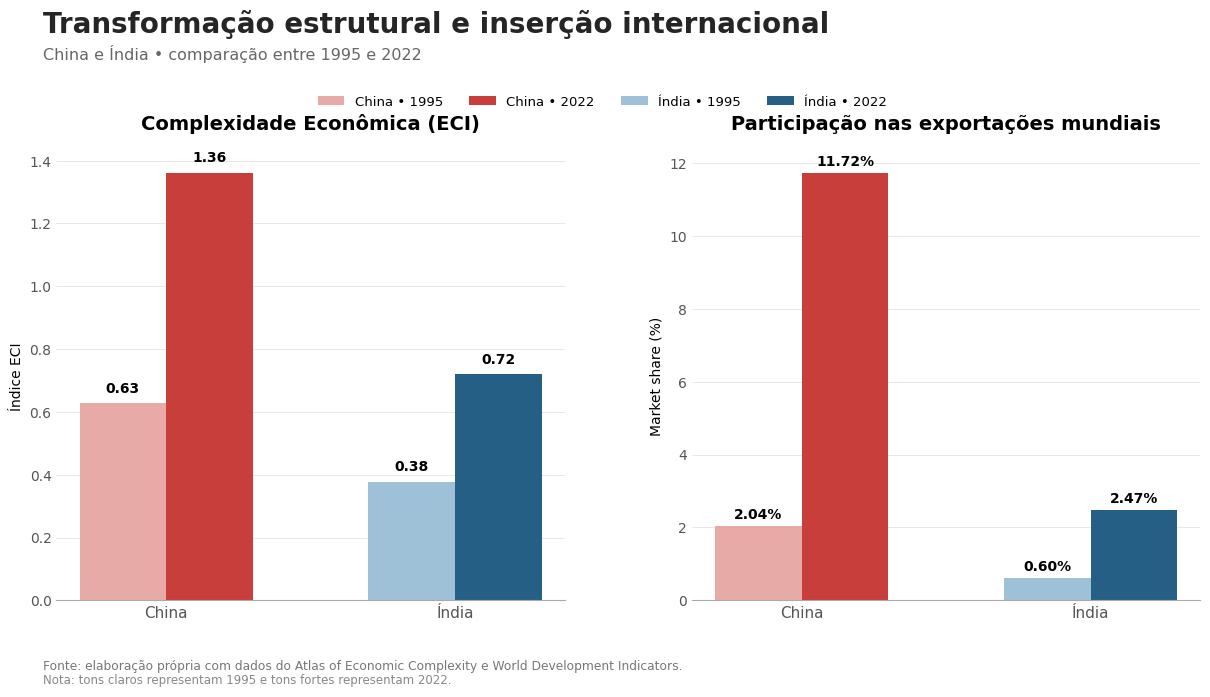

In [48]:
# ============================================================
# CÉLULA 17 — FIGURA 9 | VERSÃO FINAL COLORIDA
# 1995 x 2022 — CHINA E ÍNDIA
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ------------------------------------------------------------
# CORES
# ------------------------------------------------------------

CHINA_1995 = "#E7AAA7"
CHINA_2022 = "#C73E3A"

INDIA_1995 = "#9FC1D8"
INDIA_2022 = "#255F85"

# ------------------------------------------------------------
# DADOS
# ------------------------------------------------------------

paises = ["China", "Índia"]
x = np.arange(len(paises))
largura = 0.30

eci_1995 = [
    sintese.query('País == "China" and Ano == 1995')["ECI"].iloc[0],
    sintese.query('País == "Índia" and Ano == 1995')["ECI"].iloc[0]
]

eci_2022 = [
    sintese.query('País == "China" and Ano == 2022')["ECI"].iloc[0],
    sintese.query('País == "Índia" and Ano == 2022')["ECI"].iloc[0]
]

ms_1995 = [
    sintese.query('País == "China" and Ano == 1995')["Market Share (%)"].iloc[0],
    sintese.query('País == "Índia" and Ano == 1995')["Market Share (%)"].iloc[0]
]

ms_2022 = [
    sintese.query('País == "China" and Ano == 2022')["Market Share (%)"].iloc[0],
    sintese.query('País == "Índia" and Ano == 2022')["Market Share (%)"].iloc[0]
]

# Cores de cada barra:
# China claro/forte + Índia claro/forte
cores_1995 = [CHINA_1995, INDIA_1995]
cores_2022 = [CHINA_2022, INDIA_2022]

# ------------------------------------------------------------
# FIGURA
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(13, 6.8))

# ============================================================
# PAINEL 1 — ECI
# ============================================================

ax = axes[0]

b1 = ax.bar(
    x - largura/2,
    eci_1995,
    largura,
    color=cores_1995
)

b2 = ax.bar(
    x + largura/2,
    eci_2022,
    largura,
    color=cores_2022
)

ax.set_title(
    "Complexidade Econômica (ECI)",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.set_ylabel("Índice ECI", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(paises, fontsize=11)

# Valores
for barras in [b1, b2]:
    for barra in barras:

        h = barra.get_height()

        ax.text(
            barra.get_x() + barra.get_width()/2,
            h + 0.035,
            f"{h:.2f}",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

# ============================================================
# PAINEL 2 — MARKET SHARE
# ============================================================

ax2 = axes[1]

b3 = ax2.bar(
    x - largura/2,
    ms_1995,
    largura,
    color=cores_1995
)

b4 = ax2.bar(
    x + largura/2,
    ms_2022,
    largura,
    color=cores_2022
)

ax2.set_title(
    "Participação nas exportações mundiais",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax2.set_ylabel("Market share (%)", fontsize=10)
ax2.set_xticks(x)
ax2.set_xticklabels(paises, fontsize=11)

# Valores
for barras in [b3, b4]:
    for barra in barras:

        h = barra.get_height()

        ax2.text(
            barra.get_x() + barra.get_width()/2,
            h + 0.20,
            f"{h:.2f}%",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

# ============================================================
# PADRÃO VISUAL
# ============================================================

for eixo in axes:

    eixo.grid(
        axis="y",
        color="#D9D9D9",
        linewidth=.7,
        alpha=.60
    )

    eixo.set_axisbelow(True)

    eixo.spines["top"].set_visible(False)
    eixo.spines["right"].set_visible(False)
    eixo.spines["left"].set_visible(False)

    eixo.spines["bottom"].set_color("#AAAAAA")

    eixo.tick_params(
        colors="#555555",
        length=0
    )

# ------------------------------------------------------------
# TÍTULO
# ------------------------------------------------------------

fig.text(
    0.07, 0.965,
    "Transformação estrutural e inserção internacional",
    fontsize=20,
    fontweight="bold",
    color="#252525"
)

fig.text(
    0.07, 0.925,
    "China e Índia • comparação entre 1995 e 2022",
    fontsize=11.5,
    color="#666666"
)

# ------------------------------------------------------------
# LEGENDA — EXPLÍCITA
# ------------------------------------------------------------

legenda = [
    Patch(facecolor=CHINA_1995, label="China • 1995"),
    Patch(facecolor=CHINA_2022, label="China • 2022"),
    Patch(facecolor=INDIA_1995, label="Índia • 1995"),
    Patch(facecolor=INDIA_2022, label="Índia • 2022")
]

fig.legend(
    handles=legenda,
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.89),
    fontsize=9.5
)

# ------------------------------------------------------------
# FONTE
# ------------------------------------------------------------

fig.text(
    0.07, 0.028,
    "Fonte: elaboração própria com dados do Atlas of Economic Complexity "
    "e World Development Indicators.",
    fontsize=8.8,
    color="#777777"
)

fig.text(
    0.07, 0.007,
    "Nota: tons claros representam 1995 e tons fortes representam 2022.",
    fontsize=8.5,
    color="#888888"
)

# ------------------------------------------------------------
# LAYOUT
# ------------------------------------------------------------

plt.subplots_adjust(
    left=.08,
    right=.96,
    top=.79,
    bottom=.13,
    wspace=.25
)

# ------------------------------------------------------------
# SALVAR
# ------------------------------------------------------------

plt.savefig(
    "/content/Figura_9_Comparacao_1995_2022.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## Estratégia Econométrica

Como complemento à análise comparativa entre China e Índia, foi estimado um modelo em painel com dados internacionais para o período de **1995 a 2022**.

A amostra econométrica contém **67 países e 1.871 observações**.

A especificação principal é:

$$
DVA_{it} = \beta_1 PTF_{it} + \beta_2 HC_{it} + \beta_3 ECI_{it} + \alpha_i + \lambda_t + \varepsilon_{it}
$$

em que:

- $DVA_{it}$: participação do valor adicionado doméstico nas exportações brutas do país $i$ no ano $t$;
- $PTF_{it}$: Produtividade Total dos Fatores;
- $HC_{it}$: índice de capital humano;
- $ECI_{it}$: Índice de Complexidade Econômica;
- $\alpha_i$: efeitos fixos de país;
- $\lambda_t$: efeitos fixos de ano;
- $\varepsilon_{it}$: termo de erro.

As bases utilizadas são:

- **OECD Trade in Value Added (TiVA)** para o DVA;
- **Penn World Table 11.0** para PTF e capital humano;
- **Atlas of Economic Complexity** para o ECI.

Primeiramente, foi estimado um modelo OLS com erros-padrão robustos HC3 como referência.

Em seguida, foi estimado o modelo principal com **efeitos fixos de país e de ano e erros-padrão clusterizados por país**.

Os efeitos fixos de país controlam características não observadas invariantes no tempo de cada economia, enquanto os efeitos fixos de ano controlam choques comuns aos países em determinado período.

Os coeficientes são interpretados como **associações**, e não como efeitos causais.

O painel internacional é utilizado como evidência complementar, permanecendo **China e Índia** como os casos centrais da análise.

In [49]:
# ============================================================
# CÉLULA 18 — ECONOMETRIA
# MODELO 1: OLS DE REFERÊNCIA
# ============================================================

import statsmodels.api as sm

# Variáveis explicativas
X = reg[
    ["PTF", "HumanCapital", "ECI"]
].copy()

# Constante
X = sm.add_constant(X)

# Variável dependente
y = reg["DVA_SHARE"]

# OLS com erros robustos HC3
ols = sm.OLS(y, X).fit(
    cov_type="HC3"
)

print("=" * 70)
print("OLS — MODELO DE REFERÊNCIA")
print("=" * 70)

print(ols.summary())

OLS — MODELO DE REFERÊNCIA
                            OLS Regression Results                            
Dep. Variable:              DVA_SHARE   R-squared:                       0.170
Model:                            OLS   Adj. R-squared:                  0.168
Method:                 Least Squares   F-statistic:                     148.6
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           2.49e-86
Time:                        15:29:09   Log-Likelihood:                -6813.9
No. Observations:                1871   AIC:                         1.364e+04
Df Residuals:                    1867   BIC:                         1.366e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           74.52

In [50]:
# ============================================================
# CÉLULA 19 — MODELO PRINCIPAL
# EFEITOS FIXOS DE PAÍS E ANO
# Erros-padrão clusterizados por país
# ============================================================

!pip -q install linearmodels

from linearmodels.panel import PanelOLS

# ------------------------------------------------------------
# PREPARAR PAINEL
# ------------------------------------------------------------

reg_fe = (
    reg[
        ["country", "year", "DVA_SHARE",
         "PTF", "HumanCapital", "ECI"]
    ]
    .copy()
    .set_index(["country", "year"])
    .sort_index()
)

# ------------------------------------------------------------
# MODELO
# ------------------------------------------------------------

modelo_fe = PanelOLS(
    dependent=reg_fe["DVA_SHARE"],
    exog=reg_fe[["PTF", "HumanCapital", "ECI"]],
    entity_effects=True,   # efeitos fixos de país
    time_effects=True,     # efeitos fixos de ano
    drop_absorbed=True
)

resultado_fe = modelo_fe.fit(
    cov_type="clustered",
    cluster_entity=True
)

# ------------------------------------------------------------
# RESULTADO
# ------------------------------------------------------------

print("=" * 75)
print("MODELO PRINCIPAL — EFEITOS FIXOS DE PAÍS E ANO")
print("=" * 75)

print(resultado_fe.summary)

MODELO PRINCIPAL — EFEITOS FIXOS DE PAÍS E ANO
                          PanelOLS Estimation Summary                           
Dep. Variable:              DVA_SHARE   R-squared:                        0.1063
Estimator:                   PanelOLS   R-squared (Between):             -0.1559
No. Observations:                1871   R-squared (Within):               0.1780
Date:                Sat, Sep 12 2026   R-squared (Overall):             -0.1553
Time:                        15:29:11   Log-likelihood                   -4775.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      70.337
Entities:                          67   P-value                           0.0000
Avg Obs:                       27.925   Distribution:                  F(3,1774)
Min Obs:                       23.000                                           
Max Obs:                       28.000   F-statistic (robust): 

In [51]:
# ============================================================
# CÉLULA 20 — CHECK FINAL DA ECONOMETRIA
# ============================================================

print("=" * 72)
print("CHECK FINAL — MODELO PRINCIPAL")
print("=" * 72)

print(f"Observações: {resultado_fe.nobs}")
print(f"Países: {reg['country'].nunique()}")
print(f"Período: {reg['year'].min()}–{reg['year'].max()}")
print(f"Duplicados país-ano: {reg.duplicated(['country','year']).sum()}")

print("\nEfeitos incluídos:")
print(resultado_fe.included_effects)

print("\nTeste de Poolability:")
print(resultado_fe.f_pooled)

# ------------------------------------------------------------
# TABELA LIMPA PARA O TCC
# ------------------------------------------------------------

tabela_reg = pd.DataFrame({
    "Coeficiente": resultado_fe.params,
    "Erro-padrão": resultado_fe.std_errors,
    "Estatística t": resultado_fe.tstats,
    "p-valor": resultado_fe.pvalues
})

tabela_reg.index = [
    "Produtividade Total dos Fatores (PTF)",
    "Capital Humano",
    "Complexidade Econômica (ECI)"
]

print("\n" + "=" * 72)
print("RESULTADOS — EFEITOS FIXOS DE PAÍS E ANO")
print("=" * 72)

display(
    tabela_reg.style
    .format({
        "Coeficiente": "{:.3f}",
        "Erro-padrão": "{:.3f}",
        "Estatística t": "{:.3f}",
        "p-valor": "{:.4f}"
    })
)

print("\nR²:", round(resultado_fe.rsquared, 4))
print("R² within:", round(resultado_fe.rsquared_within, 4))

CHECK FINAL — MODELO PRINCIPAL
Observações: 1871
Países: 67
Período: 1995–2022
Duplicados país-ano: 0

Efeitos incluídos:
['Entity', 'Time']

Teste de Poolability:
Pooled F-statistic
H0: Effects are zero
Statistic: 149.5337
P-value: 0.0000
Distributed: F(93,1774)

RESULTADOS — EFEITOS FIXOS DE PAÍS E ANO


,Coeficiente,Erro-padrão,Estatística t,p-valor
Produtividade Total dos Fatores (PTF),11.946,2.681,4.456,0.0000
Capital Humano,-5.139,3.200,-1.606,0.1085
Complexidade Econômica (ECI),0.197,1.882,0.105,0.9165



R²: 0.1063
R² within: 0.178
